### Visualization settings for publication-quality figures

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def set_pub_style():
    """
    Set a consistent, publication-quality matplotlib style.

    Notes
    -----
    - Do not enforce colors here (leave color choices to individual plots).
    - Use mathtext with STIX for LaTeX-like rendering.
    """
    plt.rcParams.update({
        # Figure + saving
        "figure.figsize": (6.0, 4.2),
        # "figure.dpi": 120,  # optional; saving dpi matters more
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,

        # Typography
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "axes.titlepad": 8,
        "axes.labelpad": 6,

        # Axes / ticks
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,

        # Grid
        "grid.alpha": 0.25,
        "grid.linestyle": "-",

        # Lines / markers
        "lines.linewidth": 1.5,
        "lines.markersize": 4,

        # Legend
        "legend.frameon": False,

        # Math / formatting
        "mathtext.fontset": "stix",
        "axes.formatter.use_mathtext": True,
        # "axes.unicode_minus": True,  # consider toggling based on preference
    })

set_pub_style()

def set_nice_ticks(ax, max_ticks=6):
    """Helper to keep tick density consistent across figures."""
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_ticks))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=max_ticks))


### Simulation parameters and experimental design

In [2]:
import numpy as np

# -----------------------
# Reproducibility
# -----------------------
SEED = 2026
rng = np.random.default_rng(SEED)

# -----------------------
# Task parameters (AB task)
# -----------------------
p_reward_A = 0.7
p_reward_B = 0.3
assert 0.0 <= p_reward_A <= 1.0 and 0.0 <= p_reward_B <= 1.0

# -----------------------
# Generative parameter settings
# -----------------------
# Convention: T is temperature; internally we may use beta = 1/T.
# Labels are descriptive of parameter magnitudes, not psychological interpretations.
theta_gen_high_alpha_high_T = {"alpha": 0.3, "T": 0.7}
theta_gen_low_alpha_low_T   = {"alpha": 0.1, "T": 0.3}

for th in [theta_gen_high_alpha_high_T, theta_gen_low_alpha_low_T]:
    assert 0.0 <= th["alpha"] <= 1.0
    assert th["T"] > 0.0

# -----------------------
# Experimental design
# -----------------------
n_trials_list = [40, 80, 160, 320]   # length of each behavioral series
n_simulated_agents = 200             # per generative configuration

print("Setup")
print("Generative parameters:")
print("  high alpha / high T:", theta_gen_high_alpha_high_T)
print("  low alpha / low T:", theta_gen_low_alpha_low_T)
print("Trial counts:", n_trials_list)
print("Simulated agents per configuration:", n_simulated_agents)
print("Random seed:", SEED)


Setup
Generative parameters:
  high alpha / high T: {'alpha': 0.3, 'T': 0.7}
  low alpha / low T: {'alpha': 0.1, 'T': 0.3}
Trial counts: [40, 80, 160, 320]
Simulated agents per configuration: 200
Random seed: 2026


### Numerically stable sigmoid and log-sigmoid utilities

In [3]:
import numpy as np

# -----------------------
# Numerically stable utilities
# -----------------------

def sigmoid_stable(z):
    """
    Numerically stable sigmoid function.

    Supports both scalars and NumPy arrays.
    """
    z_arr = np.asarray(z, dtype=float)
    out = np.empty_like(z_arr, dtype=float)

    pos = z_arr >= 0
    neg = ~pos

    out[pos] = 1.0 / (1.0 + np.exp(-z_arr[pos]))
    ez = np.exp(z_arr[neg])
    out[neg] = ez / (1.0 + ez)

    return float(out) if np.isscalar(z) else out


def log_sigmoid(z):
    """
    Numerically stable computation of log(sigmoid(z)).

    Intended for scalar inputs (e.g., trial-wise log-likelihood terms).
    """
    z = float(z)
    if z >= 0:
        return -np.log1p(np.exp(-z))
    else:
        return z - np.log1p(np.exp(z))


def log1m_sigmoid(z):
    """
    Numerically stable computation of log(1 - sigmoid(z)).

    Intended for scalar inputs (e.g., trial-wise log-likelihood terms).
    """
    z = float(z)
    if z >= 0:
        return -(z + np.log1p(np.exp(-z)))
    else:
        return -np.log1p(np.exp(z))


# -----------------------
# Quick sanity checks (silent)
# -----------------------
test_vals = np.array([-20, -5, -1, 0, 1, 5, 20], dtype=float)

sig = sigmoid_stable(test_vals)
assert np.all(np.isfinite(sig))

ls = np.array([log_sigmoid(v) for v in test_vals])
l1 = np.array([log1m_sigmoid(v) for v in test_vals])

assert np.all(np.isfinite(ls)) and np.all(np.isfinite(l1))

# Stable identities (avoid unstable "direct" references)
ls_ref = np.log(sig)  # this one is usually fine
l1_ref = np.array([log_sigmoid(-v) for v in test_vals])  # exact identity

assert np.allclose(ls, ls_ref, rtol=0.0, atol=1e-12)
assert np.allclose(l1, l1_ref, rtol=0.0, atol=1e-12)


### Behavioral model specification (learning and choice rules)

In [4]:
import numpy as np

# -----------------------
# Player model interface
# -----------------------
#
# The functions below define the *interface* of a player model:
#
#   - init_state()
#   - choice_probabilities(state, params)
#   - choice_log_probabilities(state, params)
#   - update_state(state, choice, reward, params)
#
# They specify WHAT components a model must provide (learning + decision),
# without committing to a particular implementation.
#
# The raise NotImplementedError statements are intentional:
# they make this interface explicit and ensure that, if a concrete model
# is not properly assigned below, the code fails loudly rather than
# silently using an unintended implementation.
#
# A specific model (Rescorla–Wagner) is provided below as one concrete
# implementation of this interface.
#
# Conventions
# -----------
# - choice is encoded as 0=A, 1=B
# - reward is binary: 0/1


def init_state():
    """Initialize and return the internal state of the player model."""
    raise NotImplementedError


def choice_probabilities(state, params):
    """Return choice probabilities as an array [P(A), P(B)]."""
    raise NotImplementedError


def choice_log_probabilities(state, params):
    """Return log choice probabilities as an array [log P(A), log P(B)]."""
    raise NotImplementedError


def update_state(state, choice, reward, params):
    """Update the internal state after observing a choice and reward."""
    raise NotImplementedError


# -----------------------
# Rescorla–Wagner (RW) model as a special case
# -----------------------

def rw_init_state():
    """Initialize RW state: Q-values for actions A and B."""
    return np.zeros(2, dtype=float)  # Q[0] = Q_A, Q[1] = Q_B


def rw_choice_logit(state, params):
    """
    Logit for choosing A under a 2-action softmax (sigmoid form):

        z = (Q_A - Q_B) / T
    """
    Q = state
    T = params["T"]
    assert T > 0.0
    return (Q[0] - Q[1]) / T


def rw_choice_probabilities(state, params):
    """
    Sigmoid choice rule (2-action softmax form):

        P(A) = sigmoid(z),  where z = (Q_A - Q_B) / T
    """
    z = rw_choice_logit(state, params)
    pA = float(sigmoid_stable(z))
    return np.array([pA, 1.0 - pA], dtype=float)


def rw_choice_log_probabilities(state, params):
    """
    Log choice probabilities computed in a numerically stable way:

        log P(A) = log_sigmoid(z)
        log P(B) = log(1 - sigmoid(z)) = log1m_sigmoid(z)
    """
    z = rw_choice_logit(state, params)
    return np.array([log_sigmoid(z), log1m_sigmoid(z)], dtype=float)


def rw_update_state(state, choice, reward, params):
    """
    Rescorla–Wagner update for the chosen action (in-place update):

        Q_c <- Q_c + alpha * (reward - Q_c)

    Notes
    -----
    - choice is encoded as 0=A, 1=B
    - reward is binary: 0/1
    - state is modified in-place and returned
    """
    Q = state
    alpha = params["alpha"]
    Q[choice] = Q[choice] + alpha * (reward - Q[choice])
    return Q


# -----------------------
# Select active player model
# -----------------------
# To replace the player model, redefine these assignments.

init_state = rw_init_state
choice_probabilities = rw_choice_probabilities
choice_log_probabilities = rw_choice_log_probabilities
update_state = rw_update_state


### A single simulated behavioral trajectory (AB task)

In [5]:
import numpy as np

# -----------------------
# Environment conventions (AB task)
# -----------------------
ACTION_A = 0
ACTION_B = 1
ACTION_LABEL = {ACTION_A: "A", ACTION_B: "B"}


def simulate_ab_series(n_trials, params, p_reward_A, p_reward_B, rng):
    """
    Simulate a single behavioral trajectory in an AB task using the active player model.

    Notes
    -----
    This function relies on the globally selected active model functions:
    init_state, choice_probabilities, update_state.
    Run the model specification cell first.
    """
    required = ["init_state", "choice_probabilities", "update_state"]
    missing = [name for name in required if name not in globals()]
    assert not missing, (
        "Active model is not initialized. Run the 'Behavioral model specification' cell first. "
        f"Missing: {missing}"
    )

    state = init_state()

    choices = np.zeros(n_trials, dtype=int)
    rewards = np.zeros(n_trials, dtype=int)

    for t in range(n_trials):
        probs = np.asarray(choice_probabilities(state, params), dtype=float)

        s = probs.sum()
        assert np.isfinite(s) and s > 0.0
        probs = probs / s
        assert np.all(probs >= 0.0)

        choice = int(rng.choice([ACTION_A, ACTION_B], p=probs))

        p_rew = p_reward_A if choice == ACTION_A else p_reward_B
        reward = int(rng.random() < p_rew)

        state = update_state(state, choice, reward, params)

        choices[t] = choice
        rewards[t] = reward

    trials = np.column_stack([choices, rewards])
    return trials, state


# -----------------------
# Example simulation (single trajectory)
# -----------------------
# SEED = 271
# SEED = 37305
# SEED = 1011101
SEED = 1522026
rng = np.random.default_rng(SEED)

n_trials_example = 80
params_true = theta_gen_high_alpha_high_T

trials, final_state = simulate_ab_series(
    n_trials=n_trials_example,
    params=params_true,
    p_reward_A=p_reward_A,
    p_reward_B=p_reward_B,
    rng=rng,
)

print(f"True reward probabilities: A = {p_reward_A:.2f}, B = {p_reward_B:.2f}")

# If the active model is RW, the state is a 2-element array of Q-values.
if isinstance(final_state, np.ndarray) and final_state.shape == (2,):
    print(f"Final Q-values: Q_A = {final_state[ACTION_A]:.3f}, Q_B = {final_state[ACTION_B]:.3f}")

print("\nFirst 10 trials:")
for i, (choice, reward) in enumerate(trials[:10], start=1):
    print(f"{i:02d}: choice={ACTION_LABEL[int(choice)]}, reward={int(reward)}")

print("\nLast 10 trials:")
start_idx = max(0, n_trials_example - 10)
for i, (choice, reward) in enumerate(trials[start_idx:], start=start_idx + 1):
    print(f"{i:02d}: choice={ACTION_LABEL[int(choice)]}, reward={int(reward)}")


True reward probabilities: A = 0.70, B = 0.30
Final Q-values: Q_A = 0.717, Q_B = 0.487

First 10 trials:
01: choice=B, reward=0
02: choice=A, reward=1
03: choice=B, reward=0
04: choice=A, reward=0
05: choice=A, reward=1
06: choice=A, reward=1
07: choice=A, reward=0
08: choice=A, reward=1
09: choice=A, reward=1
10: choice=A, reward=0

Last 10 trials:
71: choice=B, reward=1
72: choice=A, reward=0
73: choice=B, reward=1
74: choice=A, reward=1
75: choice=B, reward=0
76: choice=A, reward=1
77: choice=A, reward=0
78: choice=B, reward=0
79: choice=A, reward=1
80: choice=B, reward=1


### Log-likelihood of the example trajectory under different parameter settings

In [6]:
# -----------------------
# Log-likelihood (active player model)
# -----------------------

def log_likelihood_ab(trials, params):
    """
    Log-likelihood of an AB trajectory under the active player model.

    Notes
    -----
    - Model-specific details are delegated to:
        * choice_log_probabilities(state, params)
        * update_state(state, choice, reward, params)
    - This avoids duplicating learning/decision equations here.
    """
    required = ["init_state", "choice_log_probabilities", "update_state"]
    missing = [name for name in required if name not in globals()]
    assert not missing, (
        "Active model is not initialized. Run the 'Behavioral model specification' cell first. "
        f"Missing: {missing}"
    )

    trials = np.asarray(trials)
    assert trials.ndim == 2 and trials.shape[1] == 2, "trials must have shape (n_trials, 2)"

    state = init_state()
    ll = 0.0

    for choice, reward in trials:
        choice = int(choice)
        reward = int(reward)

        assert choice in (0, 1), f"Invalid choice={choice}; expected 0(A) or 1(B)"
        assert reward in (0, 1), f"Invalid reward={reward}; expected 0/1"

        log_probs = choice_log_probabilities(state, params)
        ll += float(log_probs[choice])

        state = update_state(state, choice, reward, params)

    return ll


# -----------------------
# Quick sanity check: log-likelihood for true vs misspecified parameters
# -----------------------

params_true = theta_gen_high_alpha_high_T

params_bad1 = {"alpha": 0.05,                 "T": params_true["T"]}
params_bad2 = {"alpha": params_true["alpha"], "T": 2.00}
params_bad3 = {"alpha": 0.90,                 "T": 0.10}

ll_true = log_likelihood_ab(trials, params=params_true)
ll_bad1 = log_likelihood_ab(trials, params=params_bad1)
ll_bad2 = log_likelihood_ab(trials, params=params_bad2)
ll_bad3 = log_likelihood_ab(trials, params=params_bad3)

print("Log-likelihood evaluated on the same trials:")
print(f"{'case':<6} {'alpha':>8} {'T':>8} {'logL':>12}   description")
print("-" * 80)

rows = [
    ("true", params_true["alpha"], params_true["T"], ll_true, "generating parameters"),
    ("bad1", params_bad1["alpha"], params_bad1["T"], ll_bad1, "lower learning rate"),
    ("bad2", params_bad2["alpha"], params_bad2["T"], ll_bad2, "higher temperature"),
    ("bad3", params_bad3["alpha"], params_bad3["T"], ll_bad3, "high alpha, low T"),
]

for name, a, T, ll, desc in rows:
    print(f"{name:<6} {a:8.2f} {T:8.2f} {ll:12.3f}   {desc}")


Log-likelihood evaluated on the same trials:
case      alpha        T         logL   description
--------------------------------------------------------------------------------
true       0.30     0.70      -53.155   generating parameters
bad1       0.05     0.70      -53.591   lower learning rate
bad2       0.30     2.00      -53.116   higher temperature
bad3       0.90     0.10     -214.240   high alpha, low T


### Practical identifiability (single trajectory): ΔlogL contours with ridge + true/MLE

Practical identifiability (single trajectory):
  True:  alpha = 0.300, T = 0.700
  Start: alpha0 = 0.449, T0 = 1.151
  MLE:   alpha = 0.209, T = 0.976
  boundary hit: alpha=False, T=False
  success = True, message = CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


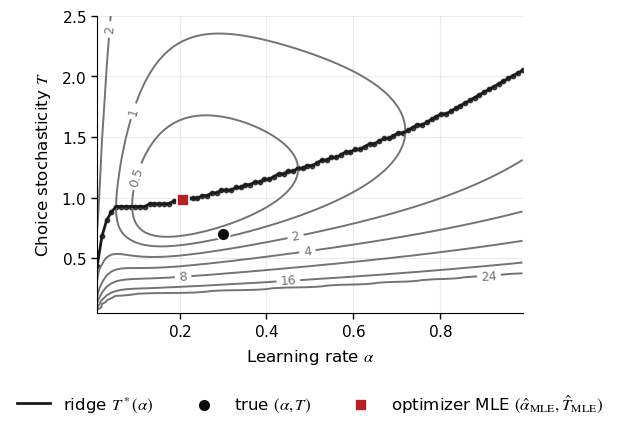

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -----------------------
# Practical identifiability (single trajectory): ΔlogL contours with ridge + true/MLE
# -----------------------

# ----- Sanity checks (avoid notebook-order issues) -----
required = ["trials", "params_true", "rng", "log_likelihood_ab", "set_nice_ticks"]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing variables/functions from previous cells: "
    + ", ".join(missing)
    + ". Run cells 1–6 first."
)

# ----- User controls -----
alpha_min, alpha_max, n_alpha = 0.01, 0.99, 90
T_min, T_max, n_T = 0.05, 2.50, 110

delta_clip = 25.0
delta_levels = [0.5, 1, 2, 4, 8, 16, 24]  # <= delta_clip

# Aesthetics
contour_color = "0.45"
contour_lw = 1.4
label_fontsize = 9
legend_y = -0.22

ridge_color = "0.10"
ridge_lw = 2.0
ridge_marker_size = 10

true_point_color = "0.05"
mle_point_color = "#B22222"
marker_edge = "white"
marker_edgewidth = 1.2
marker_size = 85

output_path = "ll_identifiability_contours_ridge_true_mle.png"

# ----- Grid evaluation -----
alpha_grid = np.linspace(alpha_min, alpha_max, n_alpha)
T_grid = np.linspace(T_min, T_max, n_T)

A, TT = np.meshgrid(alpha_grid, T_grid)  # shapes: (n_T, n_alpha)

logL = np.empty((n_T, n_alpha), dtype=float)
for i, T in enumerate(T_grid):
    for j, alpha in enumerate(alpha_grid):
        logL[i, j] = log_likelihood_ab(trials, params={"alpha": float(alpha), "T": float(T)})

logL_max = float(logL.max())

# ----- Ridge line: T*(alpha) = argmax_T logL(alpha, T) -----
ridge_T_idx = np.argmax(logL, axis=0)    # for each alpha (axis=0 corresponds to T)
ridge_T = T_grid[ridge_T_idx]
ridge_alpha = alpha_grid.copy()

# ----- Optimizer-based MLE (random start near center of bounds) -----
def neg_log_likelihood(x):
    alpha, T = float(x[0]), float(x[1])
    return -log_likelihood_ab(trials, params={"alpha": alpha, "T": T})

bounds = [(alpha_min, alpha_max), (T_min, T_max)]

alpha_center = 0.5 * (alpha_min + alpha_max)
T_center = 0.5 * (T_min + T_max)

alpha_sigma = 0.15 * (alpha_max - alpha_min)
T_sigma = 0.15 * (T_max - T_min)

alpha0 = float(np.clip(alpha_center + rng.normal(0.0, alpha_sigma), alpha_min, alpha_max))
T0 = float(np.clip(T_center + rng.normal(0.0, T_sigma), T_min, T_max))
x0 = np.array([alpha0, T0], dtype=float)

res = minimize(neg_log_likelihood, x0=x0, bounds=bounds, method="L-BFGS-B")
alpha_hat_mle, T_hat_mle = float(res.x[0]), float(res.x[1])

alpha_true = float(params_true["alpha"])
T_true = float(params_true["T"])

# Boundary-hit flags (for reporting)
eps = 1e-6
hit_alpha = (alpha_hat_mle <= alpha_min + eps) or (alpha_hat_mle >= alpha_max - eps)
hit_T = (T_hat_mle <= T_min + eps) or (T_hat_mle >= T_max - eps)

print("Practical identifiability (single trajectory):")
print(f"  True:  alpha = {alpha_true:.3f}, T = {T_true:.3f}")
print(f"  Start: alpha0 = {alpha0:.3f}, T0 = {T0:.3f}")
print(f"  MLE:   alpha = {alpha_hat_mle:.3f}, T = {T_hat_mle:.3f}")
print(f"  boundary hit: alpha={hit_alpha}, T={hit_T}")
print(f"  success = {res.success}, message = {res.message}")

# ----- ΔlogL surface (clipped for contrast) -----
Z = np.clip(logL_max - logL, 0.0, delta_clip)
levels = [lvl for lvl in delta_levels if 0.0 < lvl < delta_clip]
levels = sorted(set(levels))

# ----- Plot -----
fig, ax = plt.subplots()

cs = ax.contour(A, TT, Z, levels=levels, colors=contour_color, linewidths=contour_lw)
ax.clabel(cs, inline=True, fontsize=label_fontsize, fmt="%g")

# Ridge overlay
ax.plot(
    ridge_alpha, ridge_T,
    linestyle="-", linewidth=ridge_lw, color=ridge_color,
    label=r"ridge $T^*(\alpha)$",
)
ax.scatter(ridge_alpha, ridge_T, s=ridge_marker_size, color=ridge_color, alpha=0.8)

# True and MLE markers
ax.scatter(
    [alpha_true], [T_true],
    marker="o", s=marker_size, c=true_point_color,
    edgecolors=marker_edge, linewidths=marker_edgewidth,
    label=r"true $(\alpha, T)$",
    zorder=5,
)
ax.scatter(
    [alpha_hat_mle], [T_hat_mle],
    marker="s", s=marker_size, c=mle_point_color,
    edgecolors=marker_edge, linewidths=marker_edgewidth,
    label=r"optimizer MLE $(\hat{\alpha}_{\mathrm{MLE}}, \hat{T}_{\mathrm{MLE}})$",
    zorder=6,
)

#ax.set_title(r"Contours of $\Delta \log L$ with ridge overlay (single trajectory)")
ax.set_xlabel(r"Learning rate $\alpha$")
ax.set_ylabel(r"Choice stochasticity $T$")
ax.set_xlim(alpha_min, alpha_max)
ax.set_ylim(T_min, T_max)
set_nice_ticks(ax, max_ticks=6)

ax.legend(loc="upper center", fontsize=12, bbox_to_anchor=(0.5, legend_y), ncol=3, frameon=False)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()


### Practical identifiability (single trajectory): ΔlogL contours with true/MLE markers

  SVE = 0.146
Practical identifiability (single trajectory):
  True:  alpha = 0.300, T = 0.700
  Start: alpha0 = 0.451, T0 = 0.992
  MLE:   alpha = 0.209, T = 0.976
  boundary hit: alpha=False, T=False
  success = True, message = CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


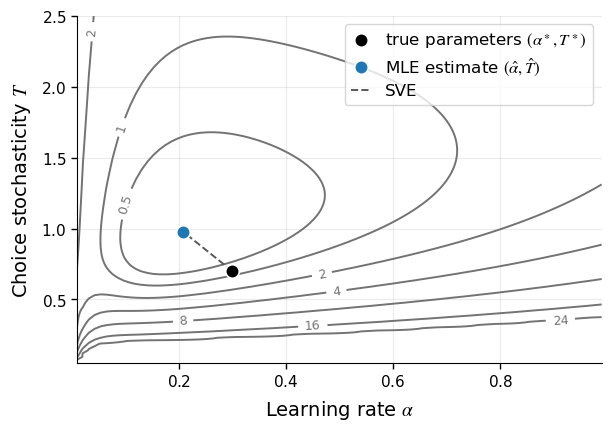

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -----------------------
# Practical identifiability (single trajectory): ΔlogL contours + true/MLE
# -----------------------

# ----- Sanity checks (avoid notebook-order issues) -----
required = ["trials", "params_true", "rng", "log_likelihood_ab", "set_nice_ticks"]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing variables/functions from previous cells: "
    + ", ".join(missing)
    + ". Run cells 1–6 first."
)

# ----- User controls -----
alpha_min, alpha_max, n_alpha = 0.01, 0.99, 90
T_min, T_max, n_T = 0.05, 2.50, 110

delta_clip = 25.0
delta_levels = [0.5, 1, 2, 4, 8, 16, 24]  # <= delta_clip

# Aesthetics
contour_color = "0.45"
contour_lw = 1.4
label_fontsize = 9

true_point_color = "black"
mle_point_color = "C0"
marker_edge = "white"
marker_edgewidth = 1.2
marker_size = 95

output_path = "ll_identifiability_contours_true_mle.png"

# ----- Grid evaluation -----
alpha_grid = np.linspace(alpha_min, alpha_max, n_alpha)
T_grid = np.linspace(T_min, T_max, n_T)

A, TT = np.meshgrid(alpha_grid, T_grid)  # shapes: (n_T, n_alpha)

logL = np.empty((n_T, n_alpha), dtype=float)
for i, T in enumerate(T_grid):
    for j, alpha in enumerate(alpha_grid):
        logL[i, j] = log_likelihood_ab(
            trials,
            params={"alpha": float(alpha), "T": float(T)}
        )

logL_max = float(logL.max())

# ----- Optimizer-based MLE (random start near center of bounds) -----
def neg_log_likelihood(x):
    alpha, T = float(x[0]), float(x[1])
    return -log_likelihood_ab(trials, params={"alpha": alpha, "T": T})

bounds = [(alpha_min, alpha_max), (T_min, T_max)]

alpha_center = 0.5 * (alpha_min + alpha_max)
T_center = 0.5 * (T_min + T_max)

alpha_sigma = 0.15 * (alpha_max - alpha_min)
T_sigma = 0.15 * (T_max - T_min)

alpha0 = float(np.clip(alpha_center + rng.normal(0.0, alpha_sigma), alpha_min, alpha_max))
T0 = float(np.clip(T_center + rng.normal(0.0, T_sigma), T_min, T_max))
x0 = np.array([alpha0, T0], dtype=float)

res = minimize(neg_log_likelihood, x0=x0, bounds=bounds, method="L-BFGS-B")
alpha_hat_mle, T_hat_mle = float(res.x[0]), float(res.x[1])

alpha_true = float(params_true["alpha"])
T_true = float(params_true["T"])

# Boundary-hit flags (for reporting)
eps = 1e-6
hit_alpha = (alpha_hat_mle <= alpha_min + eps) or (alpha_hat_mle >= alpha_max - eps)
hit_T = (T_hat_mle <= T_min + eps) or (T_hat_mle >= T_max - eps)

sve = np.sqrt(
    ((alpha_hat_mle - alpha_true) / (alpha_max - alpha_min))**2
    + ((T_hat_mle - T_true) / (T_max - T_min))**2
)
print(f"  SVE = {sve:.3f}")
print("Practical identifiability (single trajectory):")
print(f"  True:  alpha = {alpha_true:.3f}, T = {T_true:.3f}")
print(f"  Start: alpha0 = {alpha0:.3f}, T0 = {T0:.3f}")
print(f"  MLE:   alpha = {alpha_hat_mle:.3f}, T = {T_hat_mle:.3f}")
print(f"  boundary hit: alpha={hit_alpha}, T={hit_T}")
print(f"  success = {res.success}, message = {res.message}")

# ----- ΔlogL surface (clipped for contrast) -----
Z = np.clip(logL_max - logL, 0.0, delta_clip)
levels = [lvl for lvl in delta_levels if 0.0 < lvl < delta_clip]
levels = sorted(set(levels))

# ----- Plot -----
fig, ax = plt.subplots()

cs = ax.contour(
    A, TT, Z,
    levels=levels,
    colors=contour_color,
    linewidths=contour_lw
)
ax.clabel(cs, inline=True, fontsize=label_fontsize, fmt="%g")


# True and MLE markers
ax.scatter(
    [alpha_true], [T_true],
    marker="o", s=marker_size, c=true_point_color,
    edgecolors=marker_edge, linewidths=marker_edgewidth,
    label=r"true parameters $(\alpha^\ast, T^\ast)$",
    zorder=5,
)

ax.scatter(
    [alpha_hat_mle], [T_hat_mle],
    marker="o", s=marker_size, c=mle_point_color,
    edgecolors=marker_edge, linewidths=marker_edgewidth,
    label=r"MLE estimate $(\hat{\alpha}, \hat{T})$",
    zorder=6,
)
ax.plot(
    [alpha_true, alpha_hat_mle],
    [T_true, T_hat_mle],
    linestyle="--",
    linewidth=1.4,
    color="0.35",
    label="SVE",
    zorder=4,
)
ax.set_xlabel(r"Learning rate $\alpha$", fontsize=14)
ax.set_ylabel(r"Choice stochasticity $T$", fontsize=14)
ax.set_xlim(alpha_min, alpha_max)
ax.set_ylim(T_min, T_max)
set_nice_ticks(ax, max_ticks=6)

# Classical in-plot legend
ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=12,
    handlelength=1.2,
    borderpad=0.4,
    labelspacing=0.4,
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

#### MLE utilities (optimizer wrapper and boundary diagnostics)

In [34]:
import numpy as np
from scipy.optimize import minimize

# -----------------------
# Shared helpers for MLE in the AB-RW notebook
# -----------------------

def fit_mle_single_series(trials, bounds, x0):
    """
    Fit (alpha, T) by MLE for a single AB trajectory under the active player model.

    Parameters
    ----------
    trials : array-like, shape (n_trials, 2)
        Each row: (choice, reward).
    bounds : list of tuple
        [(alpha_lo, alpha_hi), (T_lo, T_hi)] for L-BFGS-B.
    x0 : array-like, shape (2,)
        Initial guess [alpha0, T0].

    Returns
    -------
    alpha_hat : float
    T_hat : float
    ll_hat : float
        Maximized log-likelihood at the optimum.
    success : bool
        Optimizer success flag.
    message : str
        Optimizer message (useful for debugging).
    """
    assert "log_likelihood_ab" in globals(), (
        "log_likelihood_ab is not defined. Run the model + log-likelihood cells first."
    )

    def neg_log_likelihood(x):
        alpha, T = float(x[0]), float(x[1])
        return -log_likelihood_ab(trials, params={"alpha": alpha, "T": T})

    res = minimize(
        neg_log_likelihood,
        x0=np.asarray(x0, dtype=float),
        bounds=bounds,
        method="L-BFGS-B",
    )
    alpha_hat, T_hat = float(res.x[0]), float(res.x[1])
    ll_hat = -float(res.fun)
    return alpha_hat, T_hat, ll_hat, bool(res.success), str(res.message)


def clip_to_bounds(x, bounds):
    """
    Clip a parameter vector x to box constraints given by bounds.
    """
    out = np.asarray(x, dtype=float).copy()
    for k, (lo, hi) in enumerate(bounds):
        out[k] = np.clip(out[k], lo, hi)
    return out


def hits_bound(x, lo, hi, tol):
    """
    Return a boolean mask indicating whether x is within tol of [lo, hi] boundaries.
    """
    x = np.asarray(x, dtype=float)
    return (x <= lo + tol) | (x >= hi - tol)


### MLE variability across repeated simulations at fixed true parameters

In [40]:
# import numpy as np
# from scipy.optimize import minimize

# -----------------------
# Repeated simulations at fixed generating parameters: computations
# -----------------------

# ----- User controls -----
params_true = theta_gen_high_alpha_high_T
n_trials_per_series = 80
n_series = 200

# Bounds for optimization
alpha_bounds = (0.001, 0.999)
T_bounds = (0.05, 5.00)

# Random-start jitter around center of bounds
alpha_init_sd_frac = 0.15
T_init_sd_frac = 0.15

# Boundary reporting tolerance
bound_tol = 1e-3

# ----- Run simulations + MLE fits -----
bounds = [alpha_bounds, T_bounds]

alpha_true = float(params_true["alpha"])
T_true = float(params_true["T"])

alpha_hats = np.full(n_series, np.nan, dtype=float)
T_hats = np.full(n_series, np.nan, dtype=float)
ll_hats = np.full(n_series, np.nan, dtype=float)
success = np.zeros(n_series, dtype=bool)

alpha_center = 0.5 * (alpha_bounds[0] + alpha_bounds[1])
T_center = 0.5 * (T_bounds[0] + T_bounds[1])

alpha_sigma = alpha_init_sd_frac * (alpha_bounds[1] - alpha_bounds[0])
T_sigma = T_init_sd_frac * (T_bounds[1] - T_bounds[0])

for s in range(n_series):
    trials_s, _ = simulate_ab_series(
        n_trials=n_trials_per_series,
        params=params_true,
        p_reward_A=p_reward_A,
        p_reward_B=p_reward_B,
        rng=rng,
    )

    x0 = np.array(
        [
            alpha_center + rng.normal(0.0, alpha_sigma),
            T_center + rng.normal(0.0, T_sigma),
        ],
        dtype=float,
    )
    x0 = clip_to_bounds(x0, bounds)

    a_hat, T_hat, ll_hat, ok, msg = fit_mle_single_series(
        trials_s,
        bounds=bounds,
        x0=x0
    )

    alpha_hats[s] = a_hat
    T_hats[s] = T_hat
    ll_hats[s] = ll_hat
    success[s] = ok

mask_ok = success & np.isfinite(alpha_hats) & np.isfinite(T_hats)

alpha_hats_ok = alpha_hats[mask_ok]
T_hats_ok = T_hats[mask_ok]

alpha_on_bound = hits_bound(
    alpha_hats_ok,
    alpha_bounds[0],
    alpha_bounds[1],
    bound_tol
)
T_on_bound = hits_bound(
    T_hats_ok,
    T_bounds[0],
    T_bounds[1],
    bound_tol
)

n_success = int(mask_ok.sum())

alpha_range = float(alpha_bounds[1] - alpha_bounds[0])
T_range = float(T_bounds[1] - T_bounds[0])

# Signed, range-normalized estimation errors
dalpha_scaled = (alpha_hats_ok - alpha_true) / alpha_range
dT_scaled = (T_hats_ok - T_true) / T_range

# SVE per repeated series
sve_repeated = np.sqrt(dalpha_scaled**2 + dT_scaled**2)

# Quantitative summaries
sve_p25, sve_p50, sve_p75 = np.percentile(sve_repeated, [25, 50, 75])
sve_p90 = np.percentile(sve_repeated, 90)
p_any_bound = float((alpha_on_bound | T_on_bound).mean())
# Quantitative summaries for reporting
boundary_hit_rate = float((alpha_on_bound | T_on_bound).mean())
median_sve = float(np.median(sve_repeated))


print("Repeated simulations at fixed generating parameters:")
print(f"  Generating parameters: alpha* = {alpha_true:.3f}, T* = {T_true:.3f}")
print(f"  Series: n = {n_series}, trials per series = {n_trials_per_series}")
print(f"  Successful finite fits: {n_success}/{n_series} = {n_success/n_series:.3f}")
print(f"  P(alpha bound hit | successful): {alpha_on_bound.mean():.3f}")
print(f"  P(T bound hit | successful):     {T_on_bound.mean():.3f}")
print(f"  P(any bound hit | successful):   {p_any_bound:.3f}")
print()
print("Recovered estimates, successful fits only:")
print(f"  median(alpha_hat) = {np.median(alpha_hats_ok):.3f}")
print(f"  median(T_hat)     = {np.median(T_hats_ok):.3f}")
print()
print("SVE, successful fits only:")
print(f"  median = {sve_p50:.3f}")
print(f"  IQR    = [{sve_p25:.3f}, {sve_p75:.3f}]")
print(f"  p90    = {sve_p90:.3f}")
print()
print(f"  boundary-hit rate: {boundary_hit_rate:.3f}")
print(f"  median SVE:        {median_sve:.3f}")

Repeated simulations at fixed generating parameters:
  Generating parameters: alpha* = 0.300, T* = 0.700
  Series: n = 200, trials per series = 80
  Successful finite fits: 200/200 = 1.000
  P(alpha bound hit | successful): 0.085
  P(T bound hit | successful):     0.015
  P(any bound hit | successful):   0.095

Recovered estimates, successful fits only:
  median(alpha_hat) = 0.359
  median(T_hat)     = 0.715

SVE, successful fits only:
  median = 0.176
  IQR    = [0.086, 0.315]
  p90    = 0.668

  boundary-hit rate: 0.095
  median SVE:        0.176


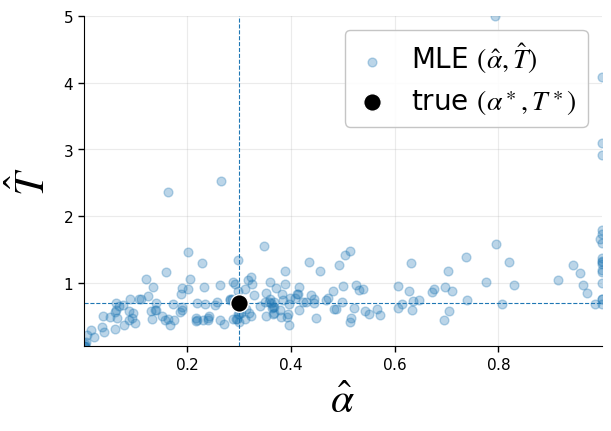

In [41]:
# -----------------------
# Left panel: MLE variability across repeated simulations
# -----------------------

output_path_left = "mle_scatter_across_series_left.png"

# ----- Sanity checks -----
required = [
    "alpha_hats_ok", "T_hats_ok",
    "alpha_true", "T_true",
    "alpha_bounds", "T_bounds",
    "set_nice_ticks"
]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing variables from previous cell: "
    + ", ".join(missing)
    + ". Run the repeated-simulation computation cell first."
)

fig, ax = plt.subplots()

# MLE cloud
mle_handle = ax.scatter(
    alpha_hats_ok,
    T_hats_ok,
    marker="o",
    s=40,
    alpha=0.30,
    rasterized=True,
    label=r"MLE $(\hat{\alpha}, \hat{T})$",
)

# Generating parameters
true_handle = ax.scatter(
    [alpha_true],
    [T_true],
    s=160,
    marker="o",
    c="black",
    edgecolors="white",
    linewidths=1.0,
    label=r"true $(\alpha^\ast, T^\ast)$",
    zorder=5,
)

# Reference lines through generating parameters
ax.axvline(alpha_true, linestyle="--", linewidth=0.8)
ax.axhline(T_true, linestyle="--", linewidth=0.8)

ax.set_xlabel(r"$\hat{\alpha}$", fontsize=30)
ax.set_ylabel(r"$\hat{T}$", fontsize=30)

ax.set_xlim(alpha_bounds[0], alpha_bounds[1])
ax.set_ylim(T_bounds[0], T_bounds[1])
set_nice_ticks(ax, max_ticks=6)

ax.legend(
    handles=[mle_handle, true_handle],
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.90,
    edgecolor="0.75",
    facecolor="white",
    fontsize=20,
    borderpad=0.4,
    labelspacing=0.4,
    handlelength=1.2,
)

plt.savefig(output_path_left, dpi=300, bbox_inches="tight")
plt.show()

# ---- Export plot style for reuse in later diagnostic cells ----
ORIG_PARAM_SCATTER_STYLE = {
    "legend_loc": ("upper left", (1.02, 1.0)),
    "true_marker_size": 90,
    "true_face": "black",
    "true_edge": "white",
    "true_lw": 1.0,
    "ref_lw": 1.2,
}

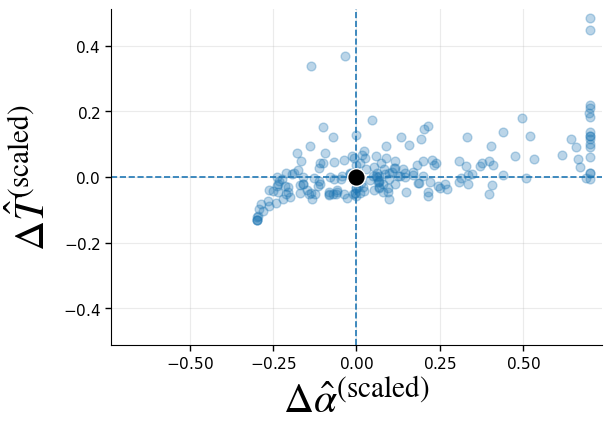

In [42]:
# -----------------------
# Right panel: signed, scaled estimation errors
# -----------------------

output_path_right = "signed_scaled_errors_scatter_right.png"

# ----- User controls -----
x_lim = None
y_lim = None

robust_q = 99.0
robust_pad = 0.05

# ----- Sanity checks -----
required = [
    "dalpha_scaled", "dT_scaled",
    "set_nice_ticks"
]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing variables from previous cell: "
    + ", ".join(missing)
    + ". Run the repeated-simulation computation cell first."
)

def robust_symmetric_limits(x, q=99.0, pad=0.05):
    m = float(np.percentile(np.abs(x), q))
    m *= (1.0 + pad)
    return (-m, m)

if x_lim is None:
    x_lim = robust_symmetric_limits(dalpha_scaled, q=robust_q, pad=robust_pad)
if y_lim is None:
    y_lim = robust_symmetric_limits(dT_scaled, q=robust_q, pad=robust_pad)

fig, ax = plt.subplots()

# Error cloud
mle_error_handle = ax.scatter(
    dalpha_scaled,
    dT_scaled,
    marker="o",
    s=40,
    alpha=0.30,
    rasterized=True,
    label=r"MLE error",
)

# Zero reference lines
ax.axvline(0.0, linestyle="--", linewidth=1.2)
ax.axhline(0.0, linestyle="--", linewidth=1.2)

# Zero-error point
zero_handle = ax.scatter(
    [0.0],
    [0.0],
    s=160,
    marker="o",
    c="black",
    edgecolors="white",
    linewidths=1.0,
    label=r"zero error",
    zorder=5,
)

ax.set_xlabel(r"$\Delta\hat{\alpha}^{(\mathrm{scaled})}$", fontsize=30)
ax.set_ylabel(r"$\Delta\hat{T}^{(\mathrm{scaled})}$", fontsize=30)

ax.set_xlim(float(x_lim[0]), float(x_lim[1]))
ax.set_ylim(float(y_lim[0]), float(y_lim[1]))
set_nice_ticks(ax, max_ticks=6)

# Usually no legend is needed here, but keep this if you want it.
# ax.legend(
#     handles=[mle_error_handle, zero_handle],
#     loc="upper right",
#     frameon=False,
#     fontsize=18
# )

plt.savefig(output_path_right, dpi=300, bbox_inches="tight")
plt.show()

### Standardized parameter error across repeated simulations (histogram + smooth density)

Standardized (range-scaled) parameter error (successful fits only):
  median = 0.1758
  IQR    = [0.0858, 0.3152]
  p90    = 0.6678
  P(bound hit) = 0.095  (tol = 0.001)


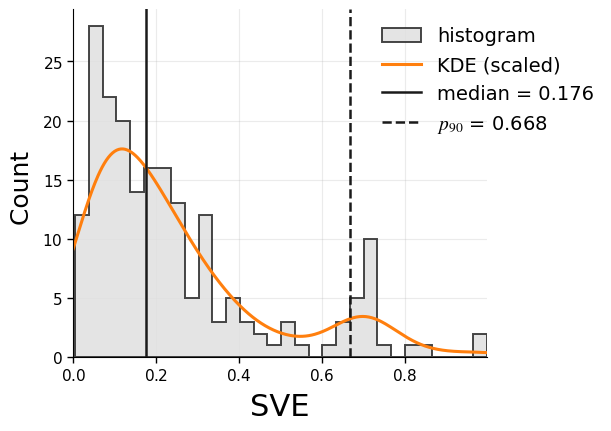

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# -----------------------
# Standardized parameter error across repeated simulations (histogram + smooth density)
# -----------------------

# ----- User controls -----
n_bins = 30
x_max = None          # e.g., 0.6 for tighter view; None = auto to max
use_log_y = False     # log-count can help for long right tails (usually keep False for papers)
kde_grid_n = 400      # resolution of KDE curve
kde_bw = "scott"      # or a float, e.g. 0.8 for slightly smoother

output_path = "standardized_error_hist_kde.png"

# ----- Sanity checks -----
required = ["alpha_hats", "T_hats", "mask_ok", "alpha_true", "T_true", "alpha_bounds", "T_bounds"]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing variables from previous cells: "
    + ", ".join(missing)
    + ". Run the MLE-across-series cell first."
)

alpha_hats_ok = np.asarray(alpha_hats, dtype=float)[mask_ok]
T_hats_ok = np.asarray(T_hats, dtype=float)[mask_ok]

alpha_true_f = float(alpha_true)
T_true_f = float(T_true)

alpha_range = float(alpha_bounds[1] - alpha_bounds[0])
T_range = float(T_bounds[1] - T_bounds[0])
assert alpha_range > 0.0 and T_range > 0.0

# Standardized (range-scaled) vector error
err_scaled = np.sqrt(
    ((alpha_hats_ok - alpha_true_f) / alpha_range) ** 2
    + ((T_hats_ok - T_true_f) / T_range) ** 2
)

# Robust summaries
p25, p50, p75 = np.percentile(err_scaled, [25, 50, 75])
p90 = np.percentile(err_scaled, 90)

# Boundary-hit probability (computed locally, robust)
bound_tol = 1e-3
alpha_on_bound = (alpha_hats_ok <= alpha_bounds[0] + bound_tol) | (alpha_hats_ok >= alpha_bounds[1] - bound_tol)
T_on_bound = (T_hats_ok <= T_bounds[0] + bound_tol) | (T_hats_ok >= T_bounds[1] - bound_tol)
p_any_bound = float((alpha_on_bound | T_on_bound).mean())

print("Standardized (range-scaled) parameter error (successful fits only):")
print(f"  median = {p50:.4f}")
print(f"  IQR    = [{p25:.4f}, {p75:.4f}]")
print(f"  p90    = {p90:.4f}")
print(f"  P(bound hit) = {p_any_bound:.3f}  (tol = {bound_tol})")

xlim_max = float(np.max(err_scaled)) if x_max is None else float(x_max)

# ----- Plot: histogram + KDE -----
fig, ax = plt.subplots()

# Histogram (light fill + dark edge; print-friendly)
ax.hist(
    err_scaled,
    bins=n_bins,
    histtype="stepfilled",
    facecolor="0.88",      # light gray fill
    edgecolor="0.15",      # dark gray edge
    linewidth=1.4,
    alpha=0.85,
    label="histogram",
    zorder=1,
)

# KDE overlay (smooth density, scaled to histogram counts)
x_grid = np.linspace(0.0, xlim_max, kde_grid_n)
kde = gaussian_kde(err_scaled, bw_method=kde_bw)
density = kde(x_grid)

# Rescale density to histogram counts (approx): N * bin_width
bin_width = xlim_max / n_bins if n_bins > 0 else 1.0
density_as_counts = density * err_scaled.size * bin_width
ax.plot(
    x_grid,
    density_as_counts,
    linewidth=2.2,
    label="KDE (scaled)",
    zorder=2,
)

# Reference lines (grayscale-friendly)
ax.axvline(
    p50,
    linestyle="-",
    linewidth=1.8,
    color="0.10",
    label=rf"median = {p50:.3f}",
    zorder=3,
)
ax.axvline(
    p90,
    linestyle="--",
    linewidth=1.8,
    color="0.10",
    label=rf"$p_{{90}}$ = {p90:.3f}",
    zorder=3,
)

#ax.set_title(r"Standardized parameter error across repeated simulations")
# ax.set_xlabel(
#     r"$e_i^{(\mathrm{scaled})}=\sqrt{\left(\frac{\hat{\alpha}-\alpha}{\alpha_{\max}-\alpha_{\min}}\right)^2"
#     r"+\left(\frac{\hat{T}-T}{T_{\max}-T_{\min}}\right)^2}$"
# )
ax.set_xlabel("SVE", fontsize=22)
#ax.set_ylabel(r"Count (histogram scale)")
ax.set_ylabel(r"Count ", fontsize=18)
ax.set_xlim(0.0, xlim_max)

if use_log_y:
    ax.set_yscale("log")

set_nice_ticks(ax, max_ticks=6)

# ax.text(
#     0.02, 0.98,
#     rf"$P(\mathrm{{bound\ hit}}) = {p_any_bound:.2f}$",
#     transform=ax.transAxes,
#     va="top", ha="left",
# )

#ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize = 14, frameon=False)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0), fontsize = 14, frameon=False)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()


### Effect of trajectory length on MLE recovery and practical identifiability

In [44]:
import numpy as np
from scipy.optimize import minimize

# -----------------------
# Effect of n_trials on MLE recovery + median and mean summaries
# -----------------------

# ----- User controls -----
params_true = theta_gen_high_alpha_high_T
n_trials_list = [40, 80, 160, 320]
n_series = 200

alpha_bounds = (0.001, 0.999)
T_bounds = (0.05, 5.00)

# Random-start jitter around center of bounds (legit, reproducible via rng)
alpha_init_sd_frac = 0.15  # fraction of (alpha_max - alpha_min)
T_init_sd_frac = 0.15      # fraction of (T_max - T_min)

bound_tol = 1e-3

# ----- Run -----
bounds = [alpha_bounds, T_bounds]
alpha_true = float(params_true["alpha"])
T_true = float(params_true["T"])

alpha_range = float(alpha_bounds[1] - alpha_bounds[0])
T_range = float(T_bounds[1] - T_bounds[0])

alpha_center = 0.5 * (alpha_bounds[0] + alpha_bounds[1])
T_center = 0.5 * (T_bounds[0] + T_bounds[1])
alpha_sigma = alpha_init_sd_frac * alpha_range
T_sigma = T_init_sd_frac * T_range

results = []

for n_trials in n_trials_list:
    alpha_hats = np.full(n_series, np.nan, dtype=float)
    T_hats = np.full(n_series, np.nan, dtype=float)
    success = np.zeros(n_series, dtype=bool)

    for s in range(n_series):
        trials_s, _ = simulate_ab_series(
            n_trials=n_trials,
            params=params_true,
            p_reward_A=p_reward_A,
            p_reward_B=p_reward_B,
            rng=rng,
        )

        # Random start near the center of bounds (not near true params)
        x0 = np.array(
            [
                alpha_center + rng.normal(0.0, alpha_sigma),
                T_center + rng.normal(0.0, T_sigma),
            ],
            dtype=float,
        )
        x0 = clip_to_bounds(x0, bounds)

        a_hat, T_hat, ll_hat, ok, msg = fit_mle_single_series(trials_s, bounds=bounds, x0=x0)
        alpha_hats[s] = a_hat
        T_hats[s] = T_hat
        success[s] = ok

    mask_ok = success & np.isfinite(alpha_hats) & np.isfinite(T_hats)

    alpha_on_bound = hits_bound(alpha_hats, alpha_bounds[0], alpha_bounds[1], bound_tol)
    T_on_bound = hits_bound(T_hats, T_bounds[0], T_bounds[1], bound_tol)
    any_on_bound = alpha_on_bound | T_on_bound

    # Summary of estimates (successful fits only)
    if mask_ok.any():
        med_alpha_hat = float(np.median(alpha_hats[mask_ok]))
        mean_alpha_hat = float(np.mean(alpha_hats[mask_ok]))
        med_T_hat = float(np.median(T_hats[mask_ok]))
        mean_T_hat = float(np.mean(T_hats[mask_ok]))
    else:
        med_alpha_hat = mean_alpha_hat = np.nan
        med_T_hat = mean_T_hat = np.nan

    # Scaled vector error + trade-off correlation (successful fits only)
    if mask_ok.any():
        da = (alpha_hats[mask_ok] - alpha_true) / alpha_range
        dT_scaled = (T_hats[mask_ok] - T_true) / T_range
        scaled_err = np.sqrt(da**2 + dT_scaled**2)

        med_err = float(np.median(scaled_err))
        mean_err = float(np.mean(scaled_err))
        p90_err = float(np.percentile(scaled_err, 90))

        r = float(np.corrcoef(da, dT_scaled)[0, 1]) if scaled_err.size > 3 else np.nan
    else:
        med_err = mean_err = p90_err = r = np.nan

    results.append(
        {
            "n_trials": int(n_trials),
            "success_rate": float(mask_ok.mean()),
            "p_bound_hit_ok": float(any_on_bound[mask_ok].mean()) if mask_ok.any() else np.nan,
            "med_alpha_hat": med_alpha_hat,
            "mean_alpha_hat": mean_alpha_hat,
            "med_T_hat": med_T_hat,
            "mean_T_hat": mean_T_hat,
            "med_err": med_err,
            "mean_err": mean_err,
            "p90_err": p90_err,
            "r_tradeoff": r,
        }
    )

# ----- Pretty print table -----
print("Effect of trajectory length on MLE recovery (fixed true parameters)")
print(f"True params: alpha = {alpha_true:.3f}, T = {T_true:.3f}")
print(f"Series per n_trials: {n_series}")
print()

header = (
    f"{'n_trials':>7}  {'success':>8}  {'P(bound|ok)':>11}  "
    f"{'med(a)':>7} {'mean(a)':>7}  {'med(T)':>7} {'mean(T)':>7}  "
    f"{'med(e*)':>8} {'mean(e*)':>9} {'p90(e*)':>9}  {'r':>7}"
)
print(header)
print("-" * len(header))

for row in results:
    print(
        f"{row['n_trials']:7d}  "
        f"{row['success_rate']:8.3f}  "
        f"{row['p_bound_hit_ok']:11.3f}  "
        f"{row['med_alpha_hat']:7.3f} {row['mean_alpha_hat']:7.3f}  "
        f"{row['med_T_hat']:7.3f} {row['mean_T_hat']:7.3f}  "
        f"{row['med_err']:8.4f} {row['mean_err']:9.4f} {row['p90_err']:9.4f}  "
        f"{row['r_tradeoff']:7.3f}"
    )


Effect of trajectory length on MLE recovery (fixed true parameters)
True params: alpha = 0.300, T = 0.700
Series per n_trials: 200

n_trials   success  P(bound|ok)   med(a) mean(a)   med(T) mean(T)   med(e*)  mean(e*)   p90(e*)        r
--------------------------------------------------------------------------------------------------------
     40     1.000        0.130    0.328   0.385    0.605   0.891    0.2001    0.2821    0.7025    0.182
     80     1.000        0.065    0.317   0.393    0.670   0.773    0.1837    0.2461    0.5686    0.461
    160     1.000        0.040    0.291   0.332    0.655   0.718    0.1295    0.1654    0.3270    0.684
    320     1.000        0.005    0.314   0.325    0.699   0.723    0.0704    0.1094    0.2152    0.421


### Full-grid parameter recovery (HEAVY): simulate, fit MLE, save raw outputs

In [45]:
import numpy as np
import json
from datetime import datetime, timezone

# -----------------------
# Full-grid recovery (HEAVY): compute + save only (no plotting)
# -----------------------

# =======================
# Sanity checks (required globals)
# =======================
required = ["rng", "simulate_ab_series", "log_likelihood_ab", "p_reward_A", "p_reward_B"]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing prerequisites from previous cells: "
    + ", ".join(missing)
    + ". Run the core model/simulation/log-likelihood cells first."
)

# =======================
# Configuration (keep "on top")
# =======================

# Grid definition
alpha_grid = np.linspace(0.05, 0.95, 31)
T_grid = np.linspace(0.10, 2.50, 31)

# Simulation design
n_trials_per_series = 80
n_replications = 80  # per grid point

# MLE bounds
alpha_bounds = (0.001, 0.999)
T_bounds = (0.05, 5.00)

# MLE initialization (LEGIT): random around center of bounds
init_sd_frac_alpha = 0.15  # fraction of alpha_range
init_sd_frac_T = 0.15      # fraction of T_range

# Outlier policy
bound_tol = 1e-3

# Output files
raw_path = "grid_recovery_raw_estimates.npz"
meta_path = "grid_recovery_raw_estimates_metadata.json"

# =======================
# Helpers (fallback if not defined in your MLE-utilities cell)
# =======================
if "clip_to_bounds" not in globals():
    def clip_to_bounds(x, bounds):
        out = np.asarray(x, dtype=float).copy()
        for k, (lo, hi) in enumerate(bounds):
            out[k] = np.clip(out[k], lo, hi)
        return out

if "hits_bound" not in globals():
    def hits_bound(x, lo, hi, tol):
        x = np.asarray(x, dtype=float)
        return (x <= lo + tol) | (x >= hi - tol)

# We prefer your shared helper that returns (a_hat, T_hat, ll_hat, ok, msg).
# If not present, we fall back to a minimal local fitter.
if "fit_mle_single_series" not in globals():
    from scipy.optimize import minimize

    def fit_mle_single_series(trials, bounds, x0):
        def neg_log_likelihood(x):
            alpha, T = float(x[0]), float(x[1])
            return -log_likelihood_ab(trials, params={"alpha": alpha, "T": T})
        res = minimize(
            neg_log_likelihood,
            x0=np.asarray(x0, dtype=float),
            bounds=bounds,
            method="L-BFGS-B",
        )
        alpha_hat, T_hat = float(res.x[0]), float(res.x[1])
        ll_hat = -float(res.fun)
        return alpha_hat, T_hat, ll_hat, bool(res.success), str(res.message)

# =======================
# Allocate arrays (raw + summaries)
# =======================
alpha_grid = np.asarray(alpha_grid, dtype=float)
T_grid = np.asarray(T_grid, dtype=float)

nA = alpha_grid.size
nT = T_grid.size
R = int(n_replications)

alpha_hats_all = np.full((nT, nA, R), np.nan, dtype=float)
T_hats_all = np.full((nT, nA, R), np.nan, dtype=float)
success_all = np.zeros((nT, nA, R), dtype=bool)

median_err_scaled = np.full((nT, nA), np.nan, dtype=float)
p_bound_hit_ok = np.full((nT, nA), np.nan, dtype=float)
success_rate = np.full((nT, nA), np.nan, dtype=float)
median_alpha_hat = np.full((nT, nA), np.nan, dtype=float)
median_T_hat = np.full((nT, nA), np.nan, dtype=float)

bounds = [alpha_bounds, T_bounds]
alpha_range = float(alpha_bounds[1] - alpha_bounds[0])
T_range = float(T_bounds[1] - T_bounds[0])

alpha_center = 0.5 * (alpha_bounds[0] + alpha_bounds[1])
T_center = 0.5 * (T_bounds[0] + T_bounds[1])
alpha_sigma = init_sd_frac_alpha * alpha_range
T_sigma = init_sd_frac_T * T_range

# =======================
# Main computation
# =======================
for iT, T_true in enumerate(T_grid):
    for jA, alpha_true in enumerate(alpha_grid):
        params_true = {"alpha": float(alpha_true), "T": float(T_true)}

        for r in range(R):
            trials_s, _ = simulate_ab_series(
                n_trials=n_trials_per_series,
                params=params_true,
                p_reward_A=p_reward_A,
                p_reward_B=p_reward_B,
                rng=rng,
            )

            # LEGIT random start near center of bounds (not near true params)
            x0 = np.array(
                [
                    alpha_center + rng.normal(0.0, alpha_sigma),
                    T_center + rng.normal(0.0, T_sigma),
                ],
                dtype=float,
            )
            x0 = clip_to_bounds(x0, bounds)

            a_hat, T_hat, ll_hat, ok, _ = fit_mle_single_series(trials_s, bounds=bounds, x0=x0)

            alpha_hats_all[iT, jA, r] = a_hat
            T_hats_all[iT, jA, r] = T_hat
            success_all[iT, jA, r] = ok

        a_hats = alpha_hats_all[iT, jA, :]
        T_hats = T_hats_all[iT, jA, :]
        ok = success_all[iT, jA, :]

        mask_ok = ok & np.isfinite(a_hats) & np.isfinite(T_hats)

        success_rate[iT, jA] = float(mask_ok.mean())

        a_on_bound = hits_bound(a_hats[mask_ok], alpha_bounds[0], alpha_bounds[1], bound_tol) if mask_ok.any() else np.array([], dtype=bool)
        T_on_bound = hits_bound(T_hats[mask_ok], T_bounds[0], T_bounds[1], bound_tol) if mask_ok.any() else np.array([], dtype=bool)
        any_on_bound = (a_on_bound | T_on_bound) if mask_ok.any() else np.array([], dtype=bool)
        p_bound_hit_ok[iT, jA] = float(any_on_bound.mean()) if mask_ok.any() else np.nan

        if mask_ok.any():
            median_alpha_hat[iT, jA] = float(np.median(a_hats[mask_ok]))
            median_T_hat[iT, jA] = float(np.median(T_hats[mask_ok]))

            da = (a_hats[mask_ok] - alpha_true) / alpha_range
            dT = (T_hats[mask_ok] - T_true) / T_range
            err_scaled = np.sqrt(da**2 + dT**2)
            median_err_scaled[iT, jA] = float(np.median(err_scaled))

# =======================
# Save raw arrays + metadata (timezone-aware UTC timestamp)
# =======================
np.savez_compressed(
    raw_path,
    alpha_grid=alpha_grid,
    T_grid=T_grid,
    alpha_hats_all=alpha_hats_all,
    T_hats_all=T_hats_all,
    success_all=success_all,
    median_err_scaled=median_err_scaled,
    p_bound_hit_ok=p_bound_hit_ok,
    success_rate=success_rate,
    median_alpha_hat=median_alpha_hat,
    median_T_hat=median_T_hat,
)

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "grid": {
        "n_alpha": int(nA),
        "n_T": int(nT),
        "alpha_min": float(alpha_grid.min()),
        "alpha_max": float(alpha_grid.max()),
        "T_min": float(T_grid.min()),
        "T_max": float(T_grid.max()),
    },
    "design": {
        "n_trials_per_series": int(n_trials_per_series),
        "n_replications": int(n_replications),
        "p_reward_A": float(p_reward_A),
        "p_reward_B": float(p_reward_B),
    },
    "mle": {
        "alpha_bounds": [float(alpha_bounds[0]), float(alpha_bounds[1])],
        "T_bounds": [float(T_bounds[0]), float(T_bounds[1])],
        "init_sd_frac_alpha": float(init_sd_frac_alpha),
        "init_sd_frac_T": float(init_sd_frac_T),
        "bound_tol": float(bound_tol),
    },
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved raw estimates:", raw_path)
print("Saved metadata:", meta_path)


Saved raw estimates: grid_recovery_raw_estimates.npz
Saved metadata: grid_recovery_raw_estimates_metadata.json


### Grid recovery diagnostics (LIGHT): median scaled error map and $P(\mathrm{bound\ hit}\mid ok)$

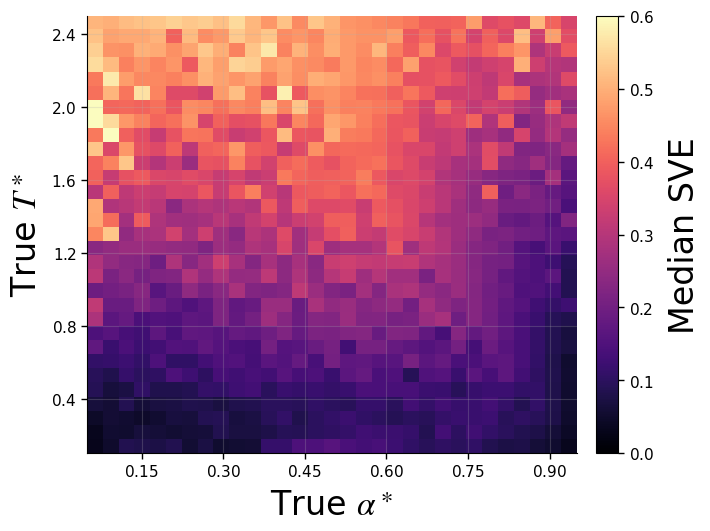

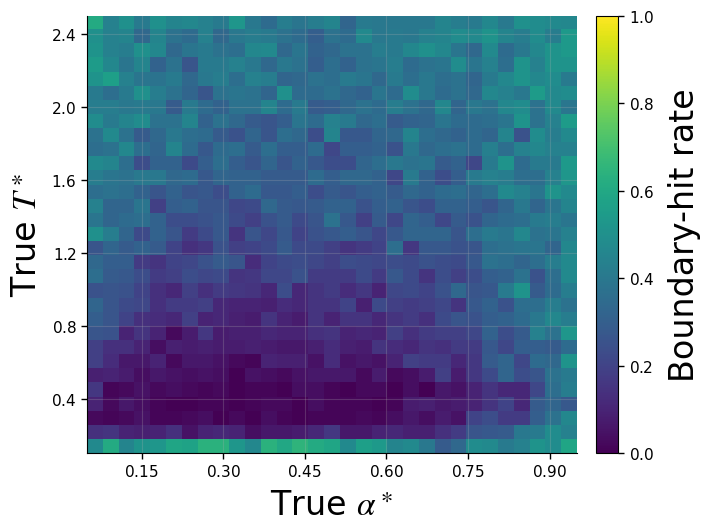

Saved figures:
  grid_recovery_median_SVE.png
  grid_recovery_boundary_hits.png


In [52]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Grid recovery diagnostics (LIGHT): plot from saved arrays
# -----------------------

# ----- User controls -----
raw_path = "grid_recovery_raw_estimates.npz"

error_clip = 0.60
err_cmap = "magma"
pbound_cmap = "viridis"
figsize = (7.0, 5.2)

fig_err_path = "grid_recovery_median_SVE.png"
fig_pbound_path = "grid_recovery_boundary_hits.png"

# ----- Sanity checks -----
assert "set_nice_ticks" in globals(), "set_nice_ticks is not defined. Run the visualization-settings cell first."

data = np.load(raw_path)
alpha_grid = data["alpha_grid"]
T_grid = data["T_grid"]
median_err_scaled = data["median_err_scaled"]
p_bound_hit_ok = data["p_bound_hit_ok"]

# ----- Plot 1: median scaled error map -----
fig, ax = plt.subplots(figsize=figsize)

Z = np.clip(median_err_scaled, 0.0, float(error_clip))

im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[float(alpha_grid.min()), float(alpha_grid.max()), float(T_grid.min()), float(T_grid.max())],
    cmap=err_cmap,
    vmin=0.0,
    vmax=float(error_clip),
)

# ax.set_title(r"Grid-based recovery: $\mathrm{median}\!\left(e^{(\mathrm{scaled})}\right)$")
ax.set_xlabel(r"True $\alpha^\ast$", fontsize=24)
ax.set_ylabel(r"True $T^\ast$", fontsize=24)

ax.set_xlim(float(alpha_grid.min()), float(alpha_grid.max()))
ax.set_ylim(float(T_grid.min()), float(T_grid.max()))
set_nice_ticks(ax, max_ticks=6)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
cbar.set_label(r"Median SVE", fontsize=24, labelpad=10)

plt.savefig(fig_err_path, dpi=300, bbox_inches="tight")
plt.show()

# ----- Plot 2: P(bound hit | ok) map -----
fig, ax = plt.subplots(figsize=figsize)

im = ax.imshow(
    p_bound_hit_ok,
    origin="lower",
    aspect="auto",
    extent=[float(alpha_grid.min()), float(alpha_grid.max()), float(T_grid.min()), float(T_grid.max())],
    cmap=pbound_cmap,
    vmin=0.0,
    vmax=1.0,
)

#ax.set_title(r"Grid diagnostic: $P(\mathrm{bound\ hit}\mid ok)$")
ax.set_xlabel(r"True $\alpha^\ast$", fontsize=24)
ax.set_ylabel(r"True $T^\ast$", fontsize=24)

ax.set_xlim(float(alpha_grid.min()), float(alpha_grid.max()))
ax.set_ylim(float(T_grid.min()), float(T_grid.max()))
set_nice_ticks(ax, max_ticks=6)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
cbar.set_label(r"Boundary-hit rate", fontsize=24, labelpad=10)

plt.savefig(fig_pbound_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(" ", fig_err_path)
print(" ", fig_pbound_path)


### Parameter recovery from random draws (HEAVY): simulate AB data, fit MLE, save raw outputs

In [49]:
import numpy as np
import json
from datetime import datetime, timezone

# -----------------------
# Parameter recovery dataset (HEAVY): random draws -> simulation -> MLE -> save
# -----------------------

# =======================
# Sanity checks (required globals)
# =======================
required = ["rng", "simulate_ab_series", "p_reward_A", "p_reward_B", "log_likelihood_ab"]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing prerequisites from previous cells: "
    + ", ".join(missing)
    + ". Run the core model/simulation/log-likelihood cells first."
)

# =======================
# Configuration (on top)
# =======================
n_datasets = 10_000
n_trials = 80

alpha_true_range = (0.05, 0.95)
T_true_range = (0.10, 2.50)

alpha_bounds = (0.001, 0.999)
T_bounds = (0.05, 5.00)

# LEGIT MLE initialization: random around center of bounds
init_sd_frac_alpha = 0.15  # fraction of (alpha_max - alpha_min)
init_sd_frac_T = 0.15      # fraction of (T_max - T_min)

bound_tol = 1e-3

output_prefix = "recovery_random_draws"
raw_path = f"{output_prefix}_raw.npz"
meta_path = f"{output_prefix}_metadata.json"

# =======================
# Helpers (fallback if not defined in your shared MLE utilities cell)
# =======================
bounds = [alpha_bounds, T_bounds]
alpha_range = float(alpha_bounds[1] - alpha_bounds[0])
T_range = float(T_bounds[1] - T_bounds[0])

alpha_center = 0.5 * (alpha_bounds[0] + alpha_bounds[1])
T_center = 0.5 * (T_bounds[0] + T_bounds[1])
alpha_sigma = init_sd_frac_alpha * alpha_range
T_sigma = init_sd_frac_T * T_range

if "clip_to_bounds" not in globals():
    def clip_to_bounds(x, bounds):
        out = np.asarray(x, dtype=float).copy()
        for k, (lo, hi) in enumerate(bounds):
            out[k] = np.clip(out[k], lo, hi)
        return out

if "hits_bound" not in globals():
    def hits_bound(x, lo, hi, tol):
        x = np.asarray(x, dtype=float)
        return (x <= lo + tol) | (x >= hi - tol)

# Prefer your shared helper (returns 5 values). If missing, fall back.
if "fit_mle_single_series" not in globals():
    from scipy.optimize import minimize

    def fit_mle_single_series(trials, bounds, x0):
        def neg_log_likelihood(x):
            a, T = float(x[0]), float(x[1])
            return -log_likelihood_ab(trials, params={"alpha": a, "T": T})
        res = minimize(
            neg_log_likelihood,
            x0=np.asarray(x0, dtype=float),
            bounds=bounds,
            method="L-BFGS-B",
        )
        a_hat, T_hat = float(res.x[0]), float(res.x[1])
        ll_hat = -float(res.fun)
        return a_hat, T_hat, ll_hat, bool(res.success), str(res.message)

# =======================
# Generate true params
# =======================
alpha_true = rng.uniform(alpha_true_range[0], alpha_true_range[1], size=n_datasets)
T_true = rng.uniform(T_true_range[0], T_true_range[1], size=n_datasets)

alpha_hat = np.full(n_datasets, np.nan, dtype=float)
T_hat = np.full(n_datasets, np.nan, dtype=float)
success = np.zeros(n_datasets, dtype=bool)

# =======================
# Simulate + fit
# =======================
for i in range(n_datasets):
    params_true = {"alpha": float(alpha_true[i]), "T": float(T_true[i])}

    trials_i, _ = simulate_ab_series(
        n_trials=n_trials,
        params=params_true,
        p_reward_A=p_reward_A,
        p_reward_B=p_reward_B,
        rng=rng,
    )

    # LEGIT init: random start near center of bounds (not near true params)
    x0 = np.array(
        [
            alpha_center + rng.normal(0.0, alpha_sigma),
            T_center + rng.normal(0.0, T_sigma),
        ],
        dtype=float,
    )
    x0 = clip_to_bounds(x0, bounds)

    a_hat, t_hat, ll_hat, ok, _ = fit_mle_single_series(trials_i, bounds=bounds, x0=x0)

    alpha_hat[i] = a_hat
    T_hat[i] = t_hat
    success[i] = ok

mask_ok = success & np.isfinite(alpha_hat) & np.isfinite(T_hat)

alpha_on_bound = hits_bound(alpha_hat, alpha_bounds[0], alpha_bounds[1], bound_tol)
T_on_bound = hits_bound(T_hat, T_bounds[0], T_bounds[1], bound_tol)
any_on_bound = alpha_on_bound | T_on_bound

print("Parameter recovery dataset (random draws):")
print(f"  n_datasets = {n_datasets}, n_trials = {n_trials}")
print(f"  success rate = {mask_ok.mean():.3f}")
print(f"  P(any bound hit | ok) = {(any_on_bound[mask_ok].mean() if mask_ok.any() else np.nan):.3f}")

# =======================
# Save raw results + metadata
# =======================
np.savez_compressed(
    raw_path,
    n_trials=int(n_trials),
    alpha_true=alpha_true,
    T_true=T_true,
    alpha_hat=alpha_hat,
    T_hat=T_hat,
    success=success,
    alpha_on_bound=alpha_on_bound,
    T_on_bound=T_on_bound,
)

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "design": {
        "n_datasets": int(n_datasets),
        "n_trials": int(n_trials),
        "p_reward_A": float(p_reward_A),
        "p_reward_B": float(p_reward_B),
    },
    "true_sampling": {
        "alpha_true_range": [float(alpha_true_range[0]), float(alpha_true_range[1])],
        "T_true_range": [float(T_true_range[0]), float(T_true_range[1])],
    },
    "mle": {
        "alpha_bounds": [float(alpha_bounds[0]), float(alpha_bounds[1])],
        "T_bounds": [float(T_bounds[0]), float(T_bounds[1])],
        "init_sd_frac_alpha": float(init_sd_frac_alpha),
        "init_sd_frac_T": float(init_sd_frac_T),
        "bound_tol": float(bound_tol),
    },
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved raw data:", raw_path)
print("Saved metadata:", meta_path)


Parameter recovery dataset (random draws):
  n_datasets = 10000, n_trials = 80
  success rate = 1.000
  P(any bound hit | ok) = 0.277
Saved raw data: recovery_random_draws_raw.npz
Saved metadata: recovery_random_draws_metadata.json


### Parameter recovery from random draws (LIGHT): scatter (pixels) + KDE contours

Parameter recovery from random draws:
  r(alpha*, alpha_hat) = 0.432
  r(T*, T_hat)         = 0.518
n=10000, n_trials=80, 
P(bound hit | ok)=0.28


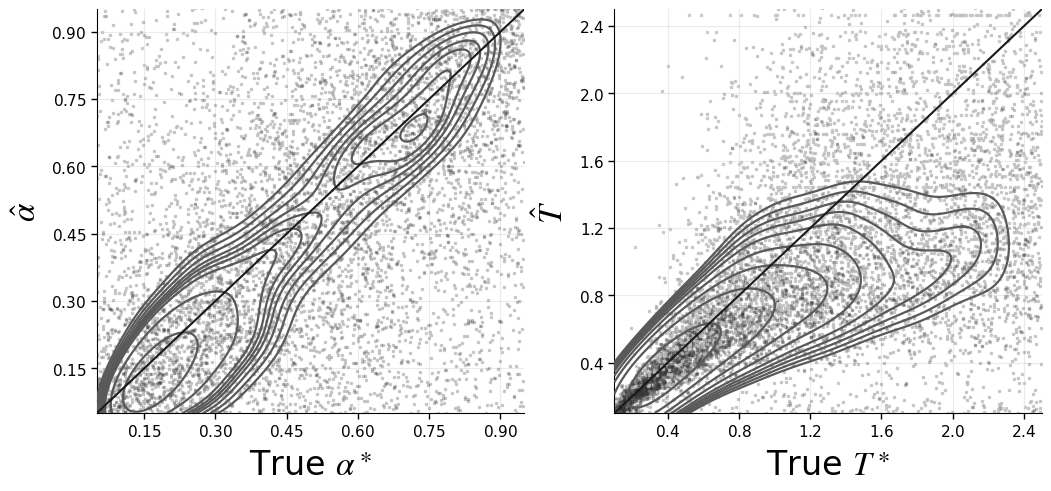

Saved figure: recovery_scatter_kde_nomarginals.png


In [54]:
from scipy.stats import pearsonr

# Quantitative summaries
r_alpha, p_alpha = pearsonr(alpha_true, alpha_hat)
r_T, p_T = pearsonr(T_true, T_hat)

print("Parameter recovery from random draws:")
print(f"  r(alpha*, alpha_hat) = {r_alpha:.3f}")
print(f"  r(T*, T_hat)         = {r_T:.3f}")

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# -----------------------
# Visualization (LIGHT): scatter (pixels) + KDE contours (no marginals)
# -----------------------

# =======================
# Configuration (on top)
# =======================
raw_path = "recovery_random_draws_raw.npz"
fig_path = "recovery_scatter_kde_nomarginals.png"

figsize = (10.4, 4.8)

# Scatter aesthetics (dense cloud)
point_alpha = 0.20
scatter_color_ok = "0.20"

# Boundary hits (optional)
highlight_boundary = True
scatter_color_bh = "0.75"

# Identity line
identity_color = "0.10"
identity_lw = 1.5

# KDE contour aesthetics
kde_levels = 9
kde_linewidths = 1.6
kde_color = "0.35"
kde_grid_n = 140  # resolution for KDE grid
kde_min_n = 200   # minimum points to attempt KDE

# Axis limits (explicit)
alpha_xlim = (0.05, 0.95)
alpha_ylim = (0.05, 0.95)
T_xlim = (0.10, 2.50)
T_ylim = (0.10, 2.50)

# =======================
# Load
# =======================
required = ["set_nice_ticks"]
missing = [name for name in required if name not in globals()]
assert not missing, "Missing set_nice_ticks; run the visualization-settings cell first."

data = np.load(raw_path)
n_trials = int(data["n_trials"])
alpha_true = data["alpha_true"]
T_true = data["T_true"]
alpha_hat = data["alpha_hat"]
T_hat = data["T_hat"]
success = data["success"].astype(bool)
alpha_on_bound = data["alpha_on_bound"].astype(bool)
T_on_bound = data["T_on_bound"].astype(bool)

mask_ok = success & np.isfinite(alpha_hat) & np.isfinite(T_hat)
any_bound = alpha_on_bound | T_on_bound
mask_ok_nb = mask_ok & (~any_bound)
mask_ok_bh = mask_ok & any_bound

# =======================
# Helper: KDE contours via scipy (x_nb, y_nb already filtered)
# =======================
def kde_contours(ax, x, y, xlim, ylim, levels=9):
    if x.size < kde_min_n:
        return

    xs = np.linspace(xlim[0], xlim[1], kde_grid_n)
    ys = np.linspace(ylim[0], ylim[1], kde_grid_n)
    X, Y = np.meshgrid(xs, ys)

    kde = gaussian_kde(np.vstack([x, y]))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    # Use quantile-based levels so contours are readable across sample sizes
    qs = np.linspace(0.70, 0.98, levels)
    lvls = np.quantile(Z, qs)
    lvls = np.unique(lvls)
    if lvls.size >= 2:
        ax.contour(X, Y, Z, levels=lvls, colors=kde_color, linewidths=kde_linewidths, zorder=3)

# =======================
# Panel function
# =======================
def panel(ax, x_true, y_hat, x_nb, y_nb, xlim, ylim, xlabel, ylabel, title=None, fontsize=24):
    # Base cloud: non-bound points as pixels
    ax.scatter(
        x_nb, y_nb,
        marker=",",
        s=1,
        alpha=point_alpha,
        c=scatter_color_ok,
        rasterized=True,
        zorder=1,
    )

    # Optional: boundary hits as lighter pixels on top
    if highlight_boundary and mask_ok_bh.any():
        ax.scatter(
            x_true[mask_ok_bh], y_hat[mask_ok_bh],
            marker=",",
            s=1,
            alpha=0.70,
            c=scatter_color_bh,
            rasterized=True,
            zorder=2,
        )

    # KDE contours on top
    kde_contours(ax, x_nb, y_nb, xlim=xlim, ylim=ylim, levels=kde_levels)

    # Identity line
    ax.plot(
        [xlim[0], xlim[1]], [xlim[0], xlim[1]],
        color=identity_color, linewidth=identity_lw,
        zorder=4,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    if title:
        ax.set_title(title, pad=8)
    set_nice_ticks(ax, max_ticks=6)

# =======================
# Build figure (two panels)
# =======================
fig, axes = plt.subplots(1, 2, figsize=figsize)

panel(
    ax=axes[0],
    x_true=alpha_true,
    y_hat=alpha_hat,
    x_nb=alpha_true[mask_ok_nb],
    y_nb=alpha_hat[mask_ok_nb],
    xlim=alpha_xlim,
    ylim=alpha_ylim,
    xlabel=r"True $\alpha^\ast$",
    ylabel=r"$\hat{\alpha}$",
    #title=r"Recovery: learning rate",
    fontsize=24
)

panel(
    ax=axes[1],
    x_true=T_true,
    y_hat=T_hat,
    x_nb=T_true[mask_ok_nb],
    y_nb=T_hat[mask_ok_nb],
    xlim=T_xlim,
    ylim=T_ylim,
    xlabel=r"True $T^\ast$",
    ylabel=r"$\hat{T}$",
    fontsize=24
    #title=r"Recovery: temperature",
)

p_bound_ok = float(any_bound[mask_ok].mean()) if mask_ok.any() else np.nan
# fig.text(
#     0.01, 0.02,
#     rf"$n={int(mask_ok.sum())}$, $n_{{trials}}={n_trials}$, "
#     rf"$P(\mathrm{{bound\ hit}}\mid ok)={p_bound_ok:.2f}$",
#     ha="left", va="bottom",
# )
print(f"n={int(mask_ok.sum())}, n_trials={n_trials}, ")
print(f"P(bound hit | ok)={p_bound_ok:.2f}")


# Better: use n_trials saved in metadata if you want it exact in the caption
# fig.text(
#     0.01, 0.06,
#     rf"$P(\mathrm{{bound\ hit}}\mid ok)={p_bound_ok:.2f}$",
#     ha="left", va="bottom",
# )

plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


### Recovery uncertainty vs trajectory length: median and IQR bands for $\hat{\alpha}$ and $\hat{T}$

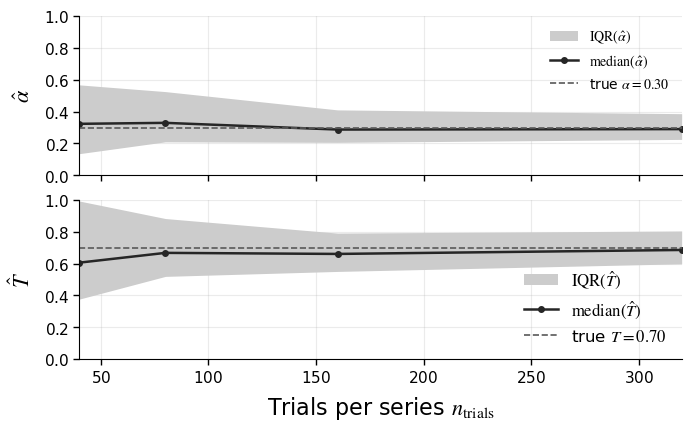

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Recovery vs trajectory length: median and IQR bands (grayscale, true values in legend)
# -----------------------

# =======================
# User controls (on top)
# =======================
n_trials_list = [40, 80, 160, 320]
n_series = 200

params_true = theta_gen_high_alpha_high_T

alpha_bounds = (0.001, 0.999)
T_bounds = (0.05, 5.00)
bounds = [alpha_bounds, T_bounds]

init_sd_frac_alpha = 0.15
init_sd_frac_T = 0.15

figsize = (6.8, 4.2)
output_path = "recovery_vs_trials_median_iqr_grayscale.png"

# Explicit y-limits (adjust after first run if you want tighter)
alpha_ylim = (0.0, 1.0)
T_ylim = (0.0, 1)

# =======================
# Sanity checks
# =======================
required = ["rng", "simulate_ab_series", "p_reward_A", "p_reward_B", "set_nice_ticks"]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing prerequisites from previous cells: "
    + ", ".join(missing)
    + ". Run the core setup cells first."
)

if "clip_to_bounds" not in globals():
    def clip_to_bounds(x, bounds):
        out = np.asarray(x, dtype=float).copy()
        for k, (lo, hi) in enumerate(bounds):
            out[k] = np.clip(out[k], lo, hi)
        return out

if "fit_mle_single_series" not in globals():
    from scipy.optimize import minimize
    assert "log_likelihood_ab" in globals(), "log_likelihood_ab is not defined. Run the log-likelihood cell first."

    def fit_mle_single_series(trials, bounds, x0):
        def neg_log_likelihood(x):
            a, T = float(x[0]), float(x[1])
            return -log_likelihood_ab(trials, params={"alpha": a, "T": T})
        res = minimize(
            neg_log_likelihood,
            x0=np.asarray(x0, dtype=float),
            bounds=bounds,
            method="L-BFGS-B",
        )
        a_hat, T_hat = float(res.x[0]), float(res.x[1])
        ll_hat = -float(res.fun)
        return a_hat, T_hat, ll_hat, bool(res.success), str(res.message)

# =======================
# Derived init parameters
# =======================
alpha_range = float(alpha_bounds[1] - alpha_bounds[0])
T_range = float(T_bounds[1] - T_bounds[0])

alpha_center = 0.5 * (alpha_bounds[0] + alpha_bounds[1])
T_center = 0.5 * (T_bounds[0] + T_bounds[1])
alpha_sigma = init_sd_frac_alpha * alpha_range
T_sigma = init_sd_frac_T * T_range

alpha_true = float(params_true["alpha"])
T_true = float(params_true["T"])

# =======================
# Run recovery as a function of n_trials
# =======================
alpha_q25 = np.full(len(n_trials_list), np.nan, dtype=float)
alpha_q50 = np.full(len(n_trials_list), np.nan, dtype=float)
alpha_q75 = np.full(len(n_trials_list), np.nan, dtype=float)

T_q25 = np.full(len(n_trials_list), np.nan, dtype=float)
T_q50 = np.full(len(n_trials_list), np.nan, dtype=float)
T_q75 = np.full(len(n_trials_list), np.nan, dtype=float)

for k, n_trials in enumerate(n_trials_list):
    a_hats = np.full(n_series, np.nan, dtype=float)
    t_hats = np.full(n_series, np.nan, dtype=float)
    ok = np.zeros(n_series, dtype=bool)

    for s in range(n_series):
        trials_s, _ = simulate_ab_series(
            n_trials=int(n_trials),
            params=params_true,
            p_reward_A=p_reward_A,
            p_reward_B=p_reward_B,
            rng=rng,
        )

        x0 = np.array(
            [
                alpha_center + rng.normal(0.0, alpha_sigma),
                T_center + rng.normal(0.0, T_sigma),
            ],
            dtype=float,
        )
        x0 = clip_to_bounds(x0, bounds)

        a_hat, t_hat, ll_hat, success, _ = fit_mle_single_series(trials_s, bounds=bounds, x0=x0)
        a_hats[s] = a_hat
        t_hats[s] = t_hat
        ok[s] = success

    mask_ok = ok & np.isfinite(a_hats) & np.isfinite(t_hats)
    if mask_ok.any():
        alpha_q25[k], alpha_q50[k], alpha_q75[k] = np.percentile(a_hats[mask_ok], [25, 50, 75])
        T_q25[k], T_q50[k], T_q75[k] = np.percentile(t_hats[mask_ok], [25, 50, 75])

# =======================
# Plot (grayscale)
# =======================
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=figsize, sharex=True, layout="constrained")

# Grayscale palette
line_dark = "0.15"
line_mid = "0.35"
band_light = "0.80"

# --- alpha panel ---
ax0.fill_between(n_trials_list, alpha_q25, alpha_q75, color=band_light, linewidth=0.0, label=r"$\mathrm{IQR}(\hat{\alpha})$")
ax0.plot(n_trials_list, alpha_q50, marker="o", linewidth=1.8, color=line_dark, label=r"$\mathrm{median}(\hat{\alpha})$")
ax0.axhline(alpha_true, linestyle="--", linewidth=1.2, color=line_mid, label=rf"true $\alpha={alpha_true:.2f}$")

# ax0.set_title(r"Recovery vs trajectory length (median and IQR bands)")
ax0.set_ylabel(r"$\hat{\alpha}$", fontsize=16)
ax0.set_xlim(min(n_trials_list), max(n_trials_list))
ax0.set_ylim(*alpha_ylim)
set_nice_ticks(ax0, max_ticks=6)
ax0.legend(loc="upper right", frameon=False)

# --- T panel ---
ax1.fill_between(n_trials_list, T_q25, T_q75, color=band_light, linewidth=0.0, label=r"$\mathrm{IQR}(\hat{T})$")
ax1.plot(n_trials_list, T_q50, marker="o", linewidth=1.8, color=line_dark, label=r"$\mathrm{median}(\hat{T})$")
ax1.axhline(T_true, linestyle="--", linewidth=1.2, color=line_mid, label=rf"true $T={T_true:.2f}$")

ax1.set_xlabel(r"Trials per series $n_{\mathrm{trials}}$", fontsize=16)
ax1.set_ylabel(r"$\hat{T}$", fontsize=16)
ax1.set_xlim(min(n_trials_list), max(n_trials_list))
ax1.set_ylim(*T_ylim)
set_nice_ticks(ax1, max_ticks=6)
ax1.legend(loc="lower right", frameon=False, fontsize=12)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()


---

### XAI overlap dataset (HEAVY): two generative mechanisms → simulation → MLE → save .npz/.json

In [57]:
import numpy as np
import json
from scipy.optimize import minimize
from datetime import datetime, timezone

# -----------------------
# Overlap dataset (HEAVY): two generating regimes -> simulation -> MLE
# -----------------------

# =======================
# Configuration
# =======================
n_trials_per_series = 80
n_series_per_regime = 800

# Two generating regimes
theta_H = theta_gen_high_alpha_high_T
theta_L = theta_gen_low_alpha_low_T

label_H = "higher_alpha_higher_T"
label_L = "lower_alpha_lower_T"

display_label_H = r"higher $\alpha^\ast$, higher $T^\ast$"
display_label_L = r"lower $\alpha^\ast$, lower $T^\ast$"

# MLE bounds
alpha_bounds = (0.001, 0.999)
T_bounds = (0.05, 5.00)
bounds = [alpha_bounds, T_bounds]

# MLE initialization: random around center of bounds
init_sd_frac_alpha = 0.15
init_sd_frac_T = 0.15

# Boundary-hit tolerance
bound_tol = 1e-3

# Output
output_prefix = f"overlap_{label_H}_vs_{label_L}_N{n_trials_per_series}"
raw_path = f"{output_prefix}_raw.npz"
meta_path = f"{output_prefix}_metadata.json"

# =======================
# Helpers
# =======================
def clip_to_bounds(x, bounds):
    out = np.asarray(x, dtype=float).copy()
    for k, (lo, hi) in enumerate(bounds):
        out[k] = np.clip(out[k], lo, hi)
    return out

def hits_bound(x, lo, hi, tol):
    x = np.asarray(x, dtype=float)
    return (x <= lo + tol) | (x >= hi - tol)

def fit_mle_single_series(trials, bounds, x0):
    def neg_log_likelihood(x):
        alpha, T = float(x[0]), float(x[1])
        return -log_likelihood_ab(trials, params={"alpha": alpha, "T": T})

    res = minimize(
        neg_log_likelihood,
        x0=np.asarray(x0, dtype=float),
        bounds=bounds,
        method="L-BFGS-B",
    )

    alpha_hat, T_hat = float(res.x[0]), float(res.x[1])
    ll_hat = -float(res.fun)

    return alpha_hat, T_hat, ll_hat, bool(res.success), str(res.message)

# =======================
# Sanity checks
# =======================
required = ["rng", "simulate_ab_series", "log_likelihood_ab", "p_reward_A", "p_reward_B"]
missing = [name for name in required if name not in globals()]
assert not missing, (
    "Missing prerequisites from previous cells: "
    + ", ".join(missing)
    + ". Run the core model/simulation/log-likelihood cells first."
)

# =======================
# Derived initialization distribution
# =======================
alpha_center = 0.5 * (alpha_bounds[0] + alpha_bounds[1])
T_center = 0.5 * (T_bounds[0] + T_bounds[1])

alpha_sigma = init_sd_frac_alpha * float(alpha_bounds[1] - alpha_bounds[0])
T_sigma = init_sd_frac_T * float(T_bounds[1] - T_bounds[0])

def run_regime(theta, n_series):
    alpha_hat = np.full(n_series, np.nan, dtype=float)
    T_hat = np.full(n_series, np.nan, dtype=float)
    ll_hat = np.full(n_series, np.nan, dtype=float)
    success = np.zeros(n_series, dtype=bool)

    for i in range(n_series):
        trials_i, _ = simulate_ab_series(
            n_trials=int(n_trials_per_series),
            params={"alpha": float(theta["alpha"]), "T": float(theta["T"])},
            p_reward_A=p_reward_A,
            p_reward_B=p_reward_B,
            rng=rng,
        )

        x0 = np.array(
            [
                alpha_center + rng.normal(0.0, alpha_sigma),
                T_center + rng.normal(0.0, T_sigma),
            ],
            dtype=float,
        )
        x0 = clip_to_bounds(x0, bounds)

        a_hat, t_hat, ll_i, ok, _ = fit_mle_single_series(
            trials_i,
            bounds=bounds,
            x0=x0,
        )

        alpha_hat[i] = a_hat
        T_hat[i] = t_hat
        ll_hat[i] = ll_i
        success[i] = ok

    alpha_on_bound = hits_bound(alpha_hat, alpha_bounds[0], alpha_bounds[1], bound_tol)
    T_on_bound = hits_bound(T_hat, T_bounds[0], T_bounds[1], bound_tol)
    any_on_bound = alpha_on_bound | T_on_bound

    mask_ok = success & np.isfinite(alpha_hat) & np.isfinite(T_hat)
    mask_interior = mask_ok & (~any_on_bound)

    return {
        "alpha_hat": alpha_hat,
        "T_hat": T_hat,
        "ll_hat": ll_hat,
        "success": success,
        "alpha_on_bound": alpha_on_bound,
        "T_on_bound": T_on_bound,
        "any_on_bound": any_on_bound,
        "mask_ok": mask_ok,
        "mask_interior": mask_interior,
    }

# =======================
# Run both regimes
# =======================
res_H = run_regime(theta_H, n_series_per_regime)
res_L = run_regime(theta_L, n_series_per_regime)

def summarize(name, theta, res):
    mask_ok = res["mask_ok"]
    mask_interior = res["mask_interior"]

    boundary_hit_rate = float(res["any_on_bound"][mask_ok].mean()) if mask_ok.any() else np.nan

    print(f"{name}: alpha*={theta['alpha']:.3f}, T*={theta['T']:.3f}")
    print(f"  successful finite fits: {int(mask_ok.sum())}/{len(mask_ok)}")
    print(f"  interior fits:          {int(mask_interior.sum())}/{len(mask_interior)}")
    print(f"  boundary-hit rate:      {boundary_hit_rate:.3f}")

print("Overlap dataset: two generating regimes")
print(f"  trials per sequence: {n_trials_per_series}")
print(f"  sequences per regime: {n_series_per_regime}")
summarize("Regime H", theta_H, res_H)
summarize("Regime L", theta_L, res_L)

# =======================
# Save raw arrays + metadata
# =======================
np.savez_compressed(
    raw_path,
    n_trials=int(n_trials_per_series),
    n_series=int(n_series_per_regime),
    alpha_bounds=np.array(alpha_bounds, dtype=float),
    T_bounds=np.array(T_bounds, dtype=float),
    bound_tol=float(bound_tol),

    label_H=label_H,
    label_L=label_L,
    display_label_H=display_label_H,
    display_label_L=display_label_L,

    alpha_true_H=float(theta_H["alpha"]),
    T_true_H=float(theta_H["T"]),
    alpha_true_L=float(theta_L["alpha"]),
    T_true_L=float(theta_L["T"]),

    alpha_hat_H=res_H["alpha_hat"],
    T_hat_H=res_H["T_hat"],
    ll_hat_H=res_H["ll_hat"],
    success_H=res_H["success"],
    any_on_bound_H=res_H["any_on_bound"],

    alpha_hat_L=res_L["alpha_hat"],
    T_hat_L=res_L["T_hat"],
    ll_hat_L=res_L["ll_hat"],
    success_L=res_L["success"],
    any_on_bound_L=res_L["any_on_bound"],
)

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "design": {
        "n_trials_per_series": int(n_trials_per_series),
        "n_series_per_regime": int(n_series_per_regime),
        "p_reward_A": float(p_reward_A),
        "p_reward_B": float(p_reward_B),
    },
    "regimes": {
        "H": {
            "label": label_H,
            "display_label": display_label_H,
            "alpha": float(theta_H["alpha"]),
            "T": float(theta_H["T"]),
        },
        "L": {
            "label": label_L,
            "display_label": display_label_L,
            "alpha": float(theta_L["alpha"]),
            "T": float(theta_L["T"]),
        },
    },
    "mle": {
        "alpha_bounds": [float(alpha_bounds[0]), float(alpha_bounds[1])],
        "T_bounds": [float(T_bounds[0]), float(T_bounds[1])],
        "init_sd_frac_alpha": float(init_sd_frac_alpha),
        "init_sd_frac_T": float(init_sd_frac_T),
        "bound_tol": float(bound_tol),
    },
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("\nSaved raw data:", raw_path)
print("Saved metadata:", meta_path)

Overlap dataset: two generating regimes
  trials per sequence: 80
  sequences per regime: 800
Regime H: alpha*=0.300, T*=0.700
  successful finite fits: 800/800
  interior fits:          740/800
  boundary-hit rate:      0.075
Regime L: alpha*=0.100, T*=0.300
  successful finite fits: 800/800
  interior fits:          772/800
  boundary-hit rate:      0.035

Saved raw data: overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_raw.npz
Saved metadata: overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_metadata.json


#### METRICS — overlap coefficient and JSD

In [58]:
import numpy as np
import json
from scipy.stats import gaussian_kde

# -----------------------
# Overlap metrics: density overlap coefficient and Jensen-Shannon divergence
# -----------------------

# =======================
# Configuration
# =======================
raw_path = "overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_raw.npz"
metrics_path = "overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_metrics.json"

# Common support for KDE
xlim = (0.0, 1.0)
ylim = (0.0, 3.0)

grid_n_alpha = 220
grid_n_T = 220
kde_bw_method = None  # None -> Scott's rule

eps = 1e-12

# =======================
# Load data
# =======================
d = np.load(raw_path, allow_pickle=True)

alpha_hat_H = np.asarray(d["alpha_hat_H"], dtype=float)
T_hat_H = np.asarray(d["T_hat_H"], dtype=float)
success_H = np.asarray(d["success_H"], dtype=bool)
any_on_bound_H = np.asarray(d["any_on_bound_H"], dtype=bool)

alpha_hat_L = np.asarray(d["alpha_hat_L"], dtype=float)
T_hat_L = np.asarray(d["T_hat_L"], dtype=float)
success_L = np.asarray(d["success_L"], dtype=bool)
any_on_bound_L = np.asarray(d["any_on_bound_L"], dtype=bool)

alpha_true_H = float(d["alpha_true_H"])
T_true_H = float(d["T_true_H"])
alpha_true_L = float(d["alpha_true_L"])
T_true_L = float(d["T_true_L"])

n_trials = int(d["n_trials"])
n_series = int(d["n_series"])

mask_H_ok = success_H & np.isfinite(alpha_hat_H) & np.isfinite(T_hat_H)
mask_L_ok = success_L & np.isfinite(alpha_hat_L) & np.isfinite(T_hat_L)

mask_H_interior = mask_H_ok & (~any_on_bound_H)
mask_L_interior = mask_L_ok & (~any_on_bound_L)

xH_i, yH_i = alpha_hat_H[mask_H_interior], T_hat_H[mask_H_interior]
xL_i, yL_i = alpha_hat_L[mask_L_interior], T_hat_L[mask_L_interior]

xH_ok, yH_ok = alpha_hat_H[mask_H_ok], T_hat_H[mask_H_ok]
xL_ok, yL_ok = alpha_hat_L[mask_L_ok], T_hat_L[mask_L_ok]

# =======================
# KDE + metrics
# =======================
def kde_grid(x, y, xlim, ylim, nx, ny, bw_method=None):
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=bw_method)

    xg = np.linspace(float(xlim[0]), float(xlim[1]), int(nx))
    yg = np.linspace(float(ylim[0]), float(ylim[1]), int(ny))

    X, Y = np.meshgrid(xg, yg)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(Y.shape)

    return X, Y, Z

def normalize_to_probability_grid(Z):
    Z = np.asarray(Z, dtype=float)
    total = float(Z.sum())
    if total <= 0.0:
        raise ValueError("KDE grid has non-positive total density.")
    return Z / total

def density_overlap_coefficient(P, Q):
    return float(np.minimum(P, Q).sum())

def jensen_shannon_divergence(P, Q, eps=1e-12):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    P = np.maximum(P, eps)
    Q = np.maximum(Q, eps)
    P = P / P.sum()
    Q = Q / Q.sum()

    M = 0.5 * (P + Q)

    kl_PM = float(np.sum(P * (np.log(P) - np.log(M))))
    kl_QM = float(np.sum(Q * (np.log(Q) - np.log(M))))

    return 0.5 * (kl_PM + kl_QM)

def compute_overlap_metrics(xH, yH, xL, yL, tag):
    if xH.size <= 10 or xL.size <= 10:
        raise ValueError(f"Too few points for KDE overlap metrics: {tag}")

    _, _, ZH = kde_grid(
        xH, yH,
        xlim=xlim,
        ylim=ylim,
        nx=grid_n_alpha,
        ny=grid_n_T,
        bw_method=kde_bw_method,
    )

    _, _, ZL = kde_grid(
        xL, yL,
        xlim=xlim,
        ylim=ylim,
        nx=grid_n_alpha,
        ny=grid_n_T,
        bw_method=kde_bw_method,
    )

    PH = normalize_to_probability_grid(ZH)
    PL = normalize_to_probability_grid(ZL)

    O = density_overlap_coefficient(PH, PL)
    JSD = jensen_shannon_divergence(PH, PL, eps=eps)

    return {
        "tag": tag,
        "n_H": int(xH.size),
        "n_L": int(xL.size),
        "O": float(O),
        "JSD": float(JSD),
    }

metrics_interior = compute_overlap_metrics(
    xH_i, yH_i,
    xL_i, yL_i,
    tag="interior fits",
)

metrics_ok = compute_overlap_metrics(
    xH_ok, yH_ok,
    xL_ok, yL_ok,
    tag="successful finite fits",
)

# =======================
# Print + save
# =======================
print("Overlap metrics based on KDE densities")
print(f"  raw data: {raw_path}")
print(f"  regimes: H=({alpha_true_H:.3f}, {T_true_H:.3f}), L=({alpha_true_L:.3f}, {T_true_L:.3f})")
print(f"  sequences per regime: {n_series}, sequence length: {n_trials}")
print(f"  KDE support: alpha_hat in [{xlim[0]}, {xlim[1]}], T_hat in [{ylim[0]}, {ylim[1]}]")
print(f"  KDE bandwidth: {'Scott default' if kde_bw_method is None else kde_bw_method}")
print()

for m in [metrics_interior, metrics_ok]:
    print(f"{m['tag']}:")
    print(f"  n_H = {m['n_H']}, n_L = {m['n_L']}")
    print(f"  density overlap coefficient O = {m['O']:.3f}")
    print(f"  Jensen-Shannon divergence JSD = {m['JSD']:.3f}")
    print()

metrics = {
    "raw_path": raw_path,
    "support": {
        "xlim": list(map(float, xlim)),
        "ylim": list(map(float, ylim)),
        "grid_n_alpha": int(grid_n_alpha),
        "grid_n_T": int(grid_n_T),
        "kde_bw_method": "Scott default" if kde_bw_method is None else str(kde_bw_method),
    },
    "regimes": {
        "H": {"alpha": alpha_true_H, "T": T_true_H},
        "L": {"alpha": alpha_true_L, "T": T_true_L},
    },
    "design": {
        "n_series_per_regime": n_series,
        "n_trials": n_trials,
    },
    "interior": metrics_interior,
    "ok": metrics_ok,
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics:", metrics_path)

Overlap metrics based on KDE densities
  raw data: overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_raw.npz
  regimes: H=(0.300, 0.700), L=(0.100, 0.300)
  sequences per regime: 800, sequence length: 80
  KDE support: alpha_hat in [0.0, 1.0], T_hat in [0.0, 3.0]
  KDE bandwidth: Scott default

interior fits:
  n_H = 740, n_L = 772
  density overlap coefficient O = 0.267
  Jensen-Shannon divergence JSD = 0.372

successful finite fits:
  n_H = 800, n_L = 800
  density overlap coefficient O = 0.308
  Jensen-Shannon divergence JSD = 0.336

Saved metrics: overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_metrics.json


### XAI overlap (LIGHT): colored recovery clouds + soft KDE contours in $(\hat{\alpha},\hat{T})$

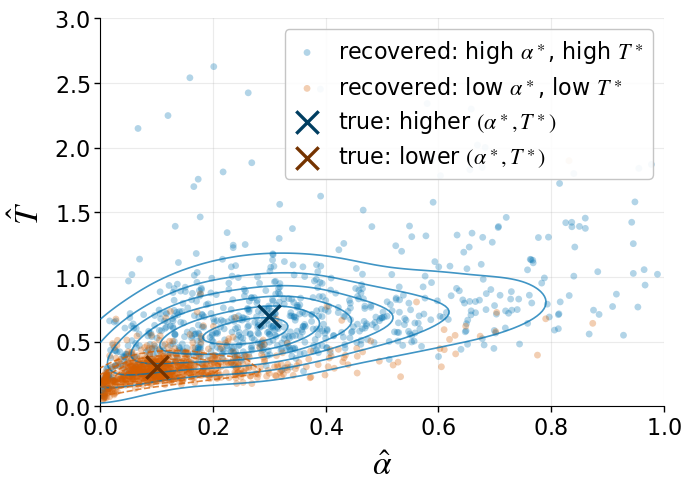

Overlap figure summary:
  raw data: overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_raw.npz
  sequences per regime: 800, sequence length: 80
  plotted interior fits: H=740, L=772
  density overlap coefficient O = 0.267
  Jensen-Shannon divergence JSD = 0.372
Saved figure: overlap_recovered_parameter_space.png


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import json

# -----------------------
# Overlap figure (LIGHT): recovered estimates + KDE contours
# -----------------------

# =======================
# Configuration
# =======================
raw_path = "overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_raw.npz"
metrics_path = "overlap_higher_alpha_higher_T_vs_lower_alpha_lower_T_N80_metrics.json"
output_path = "overlap_recovered_parameter_space.png"

# Axis limits
xlim = (0.0, 1.0)
ylim = (0.0, 3.0)

# Scatter aesthetics
point_size = 24
point_alpha = 0.3
marker = "o"
rasterize_points = True

# KDE contours
grid_n_alpha = 160
grid_n_T = 160
kde_bw_method = None
kde_min_points = 80
n_levels = 6
contour_lw = 1.2
contour_alpha = 0.75

# Font sizes
label_fs = 24
tick_fs = 16
legend_fs = 16

# Okabe-Ito palette
color_H = "#0072B2"   # blue
color_L = "#D55E00"   # vermillion

# =======================
# Helpers
# =======================
def darken_hex(hex_color, factor=0.55):
    h = hex_color.lstrip("#")
    r = int(h[0:2], 16)
    g = int(h[2:4], 16)
    b = int(h[4:6], 16)

    r = int(np.clip(r * factor, 0, 255))
    g = int(np.clip(g * factor, 0, 255))
    b = int(np.clip(b * factor, 0, 255))

    return f"#{r:02X}{g:02X}{b:02X}"

def kde_on_grid(x, y, xlim, ylim, nx, ny, bw_method=None):
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=bw_method)

    xg = np.linspace(float(xlim[0]), float(xlim[1]), int(nx))
    yg = np.linspace(float(ylim[0]), float(ylim[1]), int(ny))

    X, Y = np.meshgrid(xg, yg)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(Y.shape)

    return X, Y, Z

def contour_levels(Z, n_levels=6):
    zmax = float(np.max(Z))
    zmin = float(np.min(Z))

    lo = zmin + 0.15 * (zmax - zmin)
    hi = zmin + 0.92 * (zmax - zmin)

    return np.linspace(lo, hi, int(n_levels))

# =======================
# Load data
# =======================
d = np.load(raw_path, allow_pickle=True)

alpha_hat_H = np.asarray(d["alpha_hat_H"], dtype=float)
T_hat_H = np.asarray(d["T_hat_H"], dtype=float)
success_H = np.asarray(d["success_H"], dtype=bool)
any_on_bound_H = np.asarray(d["any_on_bound_H"], dtype=bool)

alpha_hat_L = np.asarray(d["alpha_hat_L"], dtype=float)
T_hat_L = np.asarray(d["T_hat_L"], dtype=float)
success_L = np.asarray(d["success_L"], dtype=bool)
any_on_bound_L = np.asarray(d["any_on_bound_L"], dtype=bool)

alpha_true_H = float(d["alpha_true_H"])
T_true_H = float(d["T_true_H"])
alpha_true_L = float(d["alpha_true_L"])
T_true_L = float(d["T_true_L"])

n_trials = int(d["n_trials"])
n_series = int(d["n_series"])

# Plot interior fits, consistent with reported overlap metric
mask_H = success_H & np.isfinite(alpha_hat_H) & np.isfinite(T_hat_H) & (~any_on_bound_H)
mask_L = success_L & np.isfinite(alpha_hat_L) & np.isfinite(T_hat_L) & (~any_on_bound_L)

xH, yH = alpha_hat_H[mask_H], T_hat_H[mask_H]
xL, yL = alpha_hat_L[mask_L], T_hat_L[mask_L]

color_H_true = darken_hex(color_H, factor=0.55)
color_L_true = darken_hex(color_L, factor=0.55)

# Optional: load metrics for printing
try:
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)
    O_interior = float(metrics["interior"]["O"])
    JSD_interior = float(metrics["interior"]["JSD"])
except FileNotFoundError:
    O_interior = np.nan
    JSD_interior = np.nan

# =======================
# Plot
# =======================
fig, ax = plt.subplots(figsize=(6.8, 4.8), layout="constrained")

# Recovered estimates
rec_H = ax.scatter(
    xH, yH,
    s=point_size,
    marker=marker,
    alpha=point_alpha,
    c=color_H,
    edgecolors="none",
    rasterized=rasterize_points,
    label=r"recovered: high $\alpha^\ast$, high $T^\ast$",
    zorder=1,
)

rec_L = ax.scatter(
    xL, yL,
    s=point_size,
    marker=marker,
    alpha=point_alpha,
    c=color_L,
    edgecolors="none",
    rasterized=rasterize_points,
    label=r"recovered: low $\alpha^\ast$, low $T^\ast$",
    zorder=1,
)

# KDE contours
if xH.size >= kde_min_points:
    XH, YH, ZH = kde_on_grid(
        xH, yH,
        xlim=xlim,
        ylim=ylim,
        nx=grid_n_alpha,
        ny=grid_n_T,
        bw_method=kde_bw_method,
    )
    ax.contour(
        XH, YH, ZH,
        levels=contour_levels(ZH, n_levels=n_levels),
        colors=[color_H],
        linewidths=contour_lw,
        alpha=contour_alpha,
        linestyles="-",
        zorder=3,
    )

if xL.size >= kde_min_points:
    XL, YL, ZL = kde_on_grid(
        xL, yL,
        xlim=xlim,
        ylim=ylim,
        nx=grid_n_alpha,
        ny=grid_n_T,
        bw_method=kde_bw_method,
    )
    ax.contour(
        XL, YL, ZL,
        levels=contour_levels(ZL, n_levels=n_levels),
        colors=[color_L],
        linewidths=contour_lw,
        alpha=contour_alpha,
        linestyles="--",
        zorder=3,
    )

# True generating points
true_H = ax.scatter(
    [alpha_true_H], [T_true_H],
    marker="x",
    s=260,
    c=color_H_true,
    linewidths=2.4,
    label=r"true: higher $(\alpha^\ast,T^\ast)$",
    zorder=4,
)

true_L = ax.scatter(
    [alpha_true_L], [T_true_L],
    marker="x",
    s=260,
    c=color_L_true,
    linewidths=2.4,
    label=r"true: lower $(\alpha^\ast,T^\ast)$",
    zorder=4,
)

ax.set_xlabel(r"$\hat{\alpha}$", fontsize=label_fs)
ax.set_ylabel(r"$\hat{T}$", fontsize=label_fs)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.tick_params(axis="both", labelsize=tick_fs)
set_nice_ticks(ax, max_ticks=6)

ax.legend(
    handles=[rec_H, rec_L, true_H, true_L],
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.90,
    edgecolor="0.75",
    facecolor="white",
    fontsize=legend_fs,
    borderpad=0.4,
    labelspacing=0.4,
    handlelength=1.2,
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Overlap figure summary:")
print(f"  raw data: {raw_path}")
print(f"  sequences per regime: {n_series}, sequence length: {n_trials}")
print(f"  plotted interior fits: H={int(mask_H.sum())}, L={int(mask_L.sum())}")
print(f"  density overlap coefficient O = {O_interior:.3f}")
print(f"  Jensen-Shannon divergence JSD = {JSD_interior:.3f}")
print("Saved figure:", output_path)

---

### XAI separability (LIGHT): AUC from $(\hat{\alpha},\hat{T})$ using logistic regression (CV) + RF sanity check

In [29]:
import numpy as np

# -----------------------
# XAI separability (LIGHT): AUC from (alpha_hat, T_hat)
# - LogisticRegression (linear, interpretable)
# - Optional RandomForest sanity check
# -----------------------

# =======================
# Configuration (on top)
# =======================
raw_path = "xai_overlap_high_alpha_high_T_vs_low_alpha_low_T_N80_raw.npz"

n_splits = 5
shuffle = True
random_state = 2025  # keep stable; can also reuse SEED if you prefer

use_random_forest = True

# =======================
# Load data
# =======================
d = np.load(raw_path, allow_pickle=True)

alpha_hat_A = np.asarray(d["alpha_hat_A"], dtype=float)
T_hat_A = np.asarray(d["T_hat_A"], dtype=float)
success_A = np.asarray(d["success_A"], dtype=bool)
any_on_bound_A = np.asarray(d["any_on_bound_A"], dtype=bool)

alpha_hat_B = np.asarray(d["alpha_hat_B"], dtype=float)
T_hat_B = np.asarray(d["T_hat_B"], dtype=float)
success_B = np.asarray(d["success_B"], dtype=bool)
any_on_bound_B = np.asarray(d["any_on_bound_B"], dtype=bool)

label_A = str(d["label_A"])
label_B = str(d["label_B"])

# Main mask: ok & non-bound (interior)
mask_A = success_A & np.isfinite(alpha_hat_A) & np.isfinite(T_hat_A) & (~any_on_bound_A)
mask_B = success_B & np.isfinite(alpha_hat_B) & np.isfinite(T_hat_B) & (~any_on_bound_B)

XA = np.column_stack([alpha_hat_A[mask_A], T_hat_A[mask_A]])
XB = np.column_stack([alpha_hat_B[mask_B], T_hat_B[mask_B]])

X = np.vstack([XA, XB])
y = np.concatenate([np.zeros(XA.shape[0], dtype=int), np.ones(XB.shape[0], dtype=int)])

print("XAI separability dataset (interior only):")
print(f"  raw_path: {raw_path}")
print(f"  A={label_A}: n={XA.shape[0]}   |   B={label_B}: n={XB.shape[0]}")
print()

# =======================
# AUC with cross-validation
# =======================
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

logit = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
        )),
    ]
)

auc_logit = []
for train_idx, test_idx in cv.split(X, y):
    logit.fit(X[train_idx], y[train_idx])
    scores = logit.predict_proba(X[test_idx])[:, 1]
    auc_logit.append(float(roc_auc_score(y[test_idx], scores)))

print("AUC (StratifiedKFold CV):")
print(f"  LogisticRegression (linear): mean={np.mean(auc_logit):.3f}, sd={np.std(auc_logit):.3f}  | folds={auc_logit}")

# =======================
# Optional RF sanity check
# =======================
if use_random_forest:
    from sklearn.ensemble import RandomForestClassifier

    rf = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=10,
        random_state=random_state,
        n_jobs=-1,
    )

    auc_rf = []
    for train_idx, test_idx in cv.split(X, y):
        rf.fit(X[train_idx], y[train_idx])
        scores = rf.predict_proba(X[test_idx])[:, 1]
        auc_rf.append(float(roc_auc_score(y[test_idx], scores)))

    print(f"  RandomForest (sanity check): mean={np.mean(auc_rf):.3f}, sd={np.std(auc_rf):.3f}  | folds={auc_rf}")


XAI separability dataset (interior only):
  raw_path: xai_overlap_high_alpha_high_T_vs_low_alpha_low_T_N80_raw.npz
  A=high_alpha_high_T: n=733   |   B=low_alpha_low_T: n=772

AUC (StratifiedKFold CV):
  LogisticRegression (linear): mean=0.924, sd=0.006  | folds=[0.9158936301793446, 0.9233589539711989, 0.921901228023677, 0.9338930623066726, 0.9261157755192222]
  RandomForest (sanity check): mean=0.941, sd=0.014  | folds=[0.9207306299143034, 0.9591836734693877, 0.9537503313013517, 0.9391957578435703, 0.9336942112240388]
